# Parte 2 — Preprocesamiento, Modelado y Comparación

**Curso:** Machine Learning · 2026-3

---

### Punto de partida

Este notebook continúa el EDA de la Parte 1. **Todas las decisiones de selección de
variables, imputación y transformación que se aplican aquí están justificadas allí**, y se
recuperan del artefacto `outputs/eda_resultados.pkl` para que no haya divergencia entre lo
que el análisis concluyó y lo que el modelo hace.

Los cinco hallazgos del EDA que gobiernan este notebook:

1. **El universo son 1.345.310 préstamos**, los que tienen desenlace observado
  (`Fully Paid` o `Charged Off`). Los 878.317 `Current` no tienen etiqueta: están vivos.
2. **38 columnas son fuga de información** (`recoveries`, `total_pymnt`, `settlement_*`…):
  se registran después del desembolso y quedan excluidas.
3. **La señal es débil y repartida.** De 75 variables numéricas, solo `int_rate` alcanza un
  tamaño de efecto mediano; la mediana de \|d\| es 0,0997. No cabe esperar un AUC cercano a 1.
4. **El desbalance es 4,01 : 1** (19,96 % de *default*). La exactitud es inútil como métrica:
  el clasificador trivial acierta el 80,04 %.
5. **La ausencia de datos informa.** No declarar `emp_length` eleva la tasa de *default* del
  19,53 % al 26,91 %, así que se conservan indicadores binarios de ausencia.

### Estructura

| # | Contenido |
|---|---|---|
| 0 | Entorno, utilidades e instrumentación de tiempos |
| 1 | Construcción del conjunto de modelado |
| 2 | Preprocesamiento con scikit-learn |
| 3 | Modelado con scikit-learn + `GridSearchCV` |
| 4 | Preprocesamiento con PySpark |
| 5 | Modelado con PySpark + `CrossValidator` |
| 6 | Interpretabilidad con LIME |
| 7 | Comparación de resultados |
| 8 | Reflexión crítica |

---
# 0. Entorno, utilidades e instrumentación de tiempos

Toda la comparación de rendimiento dla sección 7 depende de medir los tiempos de forma
**consistente y comparable**. Para evitar que cada bloque se cronometre a su manera, se
define un único gestor de contexto que registra cada medición en un diccionario central.

In [1]:
import os, sys, time, json, warnings, gc, math
from pathlib import Path

# --- Configuracion del entorno que PySpark necesita ANTES de importarse ---
# (1) JAVA_HOME: Spark corre sobre la JVM.
if not os.environ.get("JAVA_HOME"):
  for cand in [r"C:\Program Files\Java\jdk-21",
         r"C:\Program Files\Eclipse Adoptium\jdk-17",
         r"C:\Program Files\Java\jdk-17"]:
    if Path(cand).exists():
      os.environ["JAVA_HOME"] = cand
      break

# (2) PYSPARK_PYTHON: imprescindible y facil de pasar por alto.
# Spark lanza procesos "Python worker" para cualquier operacion que atraviese
# Python (UDF, createDataFrame desde objetos locales, RDD de Python). Si no se
# indica el interprete, usa el "python" del PATH, que rara vez es el del entorno
# virtual activo. Cuando ese interprete no tiene pyspark instalado, el worker no
# puede reconectar con el driver y el job muere con un mensaje que no dice nada
# del problema real:
#   SparkException: Python worker failed to connect back
#   SocketTimeoutException: Timed out while waiting for the Python worker
# Apuntar a sys.executable garantiza que el worker sea el MISMO interprete que
# ejecuta este notebook.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker, colors as mcolors, patches as mpatches
import seaborn as sns

import sklearn
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
               roc_auc_score, confusion_matrix, roc_curve,
               precision_recall_curve, average_precision_score,
               classification_report)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: format(v, ",.4f"))

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
  "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
  "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
  "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 9,
  "axes.grid": True, "grid.alpha": 0.25,
})

# Paleta coherente con el notebook del EDA
C_PAID, C_DEF = "#2E7D8F", "#C1554A"
C_SK,  C_SP = "#4A7C9E", "#D08C3F"   # scikit-learn / PySpark
C_NEUTRAL   = "#5B7C99"
PAL_TARGET  = {0: C_PAID, 1: C_DEF}

SEED = 42
np.random.seed(SEED)

print("Python   :", sys.version.split()[0])
print("numpy    :", np.__version__)
print("pandas   :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("JAVA_HOME  :", os.environ.get("JAVA_HOME", "<no definido>"))
print("PYSPARK_PYTHON:", os.environ["PYSPARK_PYTHON"])

Python      : 3.11.14
numpy       : 1.25.2
pandas      : 2.3.3
scikit-learn: 1.3.0
JAVA_HOME   : C:\Program Files\Java\jdk-21
PYSPARK_PYTHON: <entorno de Python>\python.exe


In [2]:
# ----------------------------------------------------------------- rutas
BASE = Path.cwd()
if not (BASE / "data_tarea_1").exists() and (BASE.parent / "data_tarea_1").exists():
  BASE = BASE.parent

CSV_ACC = BASE / "data_tarea_1" / "accepted_2007_to_2018q4.csv" / "accepted_2007_to_2018Q4.csv"
OUT_DIR = BASE / "outputs"
OUT_DIR.mkdir(exist_ok=True)
EDA_PKL = OUT_DIR / "eda_resultados.pkl"

assert CSV_ACC.exists(), "No se encuentra el CSV: " + str(CSV_ACC)
print("Proyecto :", BASE)
print("CSV   : {} ({:.2f} GB)".format(CSV_ACC.name, CSV_ACC.stat().st_size / 1e9))
print("EDA prev.:", "disponible" if EDA_PKL.exists() else "NO ENCONTRADO (ejecuta 01_eda.ipynb)")

Proyecto : <directorio del proyecto>
CSV      : accepted_2007_to_2018Q4.csv (1.68 GB)
EDA prev.: disponible


In [3]:
# ============================================================================
# INSTRUMENTACION DE TIEMPOS
# Un unico mecanismo para todas las mediciones del notebook, de modo que la
# comparacion del sección 7 sea homogenea y no dependa de como midio cada bloque.
# ============================================================================
TIEMPOS = {}

class cronometro:
  """Gestor de contexto que mide un bloque y lo registra en TIEMPOS."""
  def __init__(self, clave, mostrar=True):
    self.clave, self.mostrar = clave, mostrar
  def __enter__(self):
    self.t0 = time.perf_counter()
    return self
  def __exit__(self, *exc):
    self.dt = time.perf_counter() - self.t0
    TIEMPOS[self.clave] = self.dt
    if self.mostrar:
      print(" [tiempo] {:<44} {:>9.2f} s".format(self.clave, self.dt))
    return False

def human_int(n):
  return format(int(n), ",d").replace(",", ".")

def show(obj, titulo=None):
  if titulo:
    print()
    print(titulo)
    print("-" * min(len(titulo), 110))
  display(obj)

def metricas_clasificacion(y_true, y_pred, y_prob, nombre):
  """Bateria de metricas exigida por el diseño del estudio (la evaluación)."""
  return {
    "modelo":  nombre,
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall":  recall_score(y_true, y_pred, zero_division=0),
    "f1":    f1_score(y_true, y_pred, zero_division=0),
    "roc_auc":  roc_auc_score(y_true, y_prob),
    "avg_prec": average_precision_score(y_true, y_prob),
  }

def dibujar_matriz_confusion(cm, ax, titulo, cmap="Blues"):
  """Matriz de confusion con conteos y porcentajes por fila."""
  cm = np.asarray(cm, dtype=float)
  pct = 100 * cm / cm.sum(axis=1, keepdims=True)
  im = ax.imshow(pct, cmap=cmap, vmin=0, vmax=100)
  etq = ["Pagado (0)", "Default (1)"]
  ax.set_xticks([0, 1]); ax.set_xticklabels(etq, fontsize=9)
  ax.set_yticks([0, 1]); ax.set_yticklabels(etq, fontsize=9, rotation=90, va="center")
  ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
  nombres = [["VN", "FP"], ["FN", "VP"]]
  for i in range(2):
    for j in range(2):
      ax.text(j, i, "{}\n{}\n{:.1f} %".format(nombres[i][j],
          human_int(cm[i, j]), pct[i, j]),
          ha="center", va="center", fontsize=9.5,
          color="white" if pct[i, j] > 55 else "black",
          fontweight="bold")
  ax.set_title(titulo)
  ax.grid(False)
  return im

print("Utilidades listas: cronometro, metricas_clasificacion, dibujar_matriz_confusion")

Utilidades listas: cronometro, metricas_clasificacion, dibujar_matriz_confusion


## 0.1 Configuración de coste

Este notebook entrena **dos** búsquedas de hiperparámetros sobre 1,3 millones de filas, así
que su coste no es despreciable y conviene declararlo por adelantado en lugar de descubrirlo
a mitad de la ejecución.

`CV_FOLDS = 2`: se fija `numFolds = 2` para el `CrossValidator` de Spark y no
dice nada del `cv` de `GridSearchCV` (cuyo valor por defecto es 5). Se usa **el mismo valor en
los dos motores** —el extremo inferior del rango permitido— por dos razones: con 5 particiones
en scikit-learn y 3 en Spark la comparación mediría la diferencia de carga (45 ajustes frente
a 27) en lugar del rendimiento de los motores; y con 1,3 millones de filas, cada partición de
validación contiene ~450.000 registros, de modo que la estimación del AUC es estable sin
necesidad de más réplicas.

`MODO_RAPIDO = True`: los experimentos de la sección 7.3 y sección 7.4 (escalabilidad, efecto de la caché y
del número de particiones) no vienen requeridos, pero son lo que permite responder **con
mediciones** a sus preguntas de reflexión. Se ejecutan con un modelo pequeño
(`numTrees = 20`, `maxDepth = 8`), y esto no es solo una concesión al tiempo de cómputo: lo que
esos experimentos miden es el **sobrecoste de mover y planificar datos**, no el de calcular. Con
un modelo pequeño ese sobrecoste representa una fracción mayor del total y por tanto se aísla
**mejor**, no peor. Ponerlo en `False` los repite con `numTrees = 50`, `maxDepth = 10`.

### Coste esperado

Medido en esta máquina (12 núcleos, 25,5 GB), un ajuste de `RandomForest` sobre 1,08 millones de
filas cuesta **6,4 s** en scikit-learn y **43,5 s** en PySpark con la configuración de referencia
de 400 particiones, para `numTrees = 10, maxDepth = 5`. En el extremo caro de la rejilla
(`100, 15`) son **129 s** frente a **más de 780 s**.

El tiempo real de esta ejecución fue de **3 h 42 min**, de las cuales **2 h 29 min** las
consumió la validación cruzada de Spark. Conviene ejecutarlo primero con `MODO_PRUEBA = True`,
que valida las 50 celdas en unos minutos usando una fracción de los datos.

In [4]:
# ============================================================================
# CONFIGURACION DE COSTE
# ============================================================================
MODO_PRUEBA = False    # True -> valida el notebook completo con una fraccion de datos
MODO_RAPIDO = True     # experimentos adicionales con modelos pequenos (ver 0.1)
FILAS_PRUEBA = 400_000   # filas que se leen cuando MODO_PRUEBA esta activo

CV_FOLDS = 2        # particiones de validacion cruzada, IGUAL en ambos motores
# Rejilla del diseño (reducida solo en modo prueba, para ejercitar la maquinaria sin coste)
MALLA = ({"n_estimators": [10, 50], "max_depth": [5]} if MODO_PRUEBA
     else {"n_estimators": [10, 50, 100], "max_depth": [5, 10, 15]})

# Experimento de escalabilidad de la sección 7.3
TAMANOS_ESCALA = ([50_000, 400_000] if MODO_RAPIDO
         else [50_000, 150_000, 400_000, 800_000, None])  # None = todo el train
NE_ESCALA, MD_ESCALA = (20, 8) if MODO_RAPIDO else (50, 10)

# Hiperparametros de los experimentos de cache y particiones (sección 7.4)
NE_T, MD_T = (20, 8) if MODO_RAPIDO else (50, 10)

n_combos = len(MALLA["n_estimators"]) * len(MALLA["max_depth"])
n_ajustes = n_combos * CV_FOLDS

if MODO_PRUEBA:
  print("*** MODO_PRUEBA ACTIVO: {} filas, rejilla reducida. NO es el resultado final. ***"
     .format(human_int(FILAS_PRUEBA)))
  print()
print("Rejilla          : {} combinaciones".format(n_combos))
print("Particiones de CV      : {}".format(CV_FOLDS))
print("Ajustes por motor      : {} (+1 refit final)".format(n_ajustes))
print("Modo rapido         : {}".format(MODO_RAPIDO))
print()
print("AVISO DE COSTE: en una maquina de 12 nucleos, la busqueda de scikit-learn tarda")
print("unos 11 minutos y la de PySpark unas 2,5 horas, por el sobrecoste del")
print("particionado. El tiempo total del notebook se mide y se reporta en")
print("la sección 7.2; los valores concretos de ESTA ejecucion apareceran alli.")

Rejilla                    : 9 combinaciones
Particiones de CV           : 2
Ajustes por motor           : 18 (+1 refit final)
Modo rapido                 : True

AVISO DE COSTE: en una maquina de 12 nucleos, la busqueda de scikit-learn tarda
unos 11 minutos y la de PySpark unas 2,5 horas, por el sobrecoste del
particionado. El tiempo total del notebook se mide y se reporta en
la sección 7.2; los valores concretos de ESTA ejecucion apareceran alli.


---
# 1. Construcción del conjunto de modelado

## 1.1 Selección de variables: qué entra, qué no, y por qué

Se indica en la el preprocesamiento con scikit-learn usar *"`loan_amnt`, `int_rate`, `fico_range_high`,
`emp_length`, `annual_inc`, `purpose`, `home_ownership`, `dti`, `addr_state`, **etc.**"*. Ese
"etc." se resuelve con las conclusiones del EDA, no arbitrariamente. Las reglas aplicadas:

**Se incluye** toda variable que (a) exista en el momento de la solicitud, (b) tenga menos
del 30 % de nulos, y (c) muestre algún poder discriminante en el análisis bivariado.

**Se excluye, con motivo explícito:**

| Excluida | Motivo ( del EDA) |
|---|---|
| Las 38 columnas post-desembolso | Fuga de información: el modelo alcanzaría AUC ≈ 1 y sería inservible (sección 3.1) |
| `sub_grade` | V de Cramér ≈ 1 con `grade`: redundancia perfecta. Se conserva `grade`, más parsimonioso (sección 5.6) |
| `fico_range_low` | r = **+1,0000** con `fico_range_high`: la misma variable desplazada 4 puntos (sección 5.5.1) |
| `funded_amnt`, `funded_amnt_inv`, `installment` | r entre 0,95 y 0,9996 con `loan_amnt` (sección 5.5.1) |
| `num_sats` | r = +0,9987 con `open_acc` (sección 5.5.1) |
| `disbursement_method` | V de Cramér = **0,000** con el objetivo: poder discriminante nulo (sección 7.2) |
| El bloque de buró de 2012 (`all_util`, `il_util`, `total_bal_il`, `open_acc_6m`…) | **Ver nota abajo** |
| `sec_app_*`, `*_joint` | 98,6 % de nulos; su información ya está en `application_type` (sección 7.4) |
| `zip_code`, `emp_title`, `title`, `desc`, `url`, `id`, `member_id`, `policy_code` | Identificadores, texto libre o constantes (sección 7.4) |
| `issue_year`, `issue_d` | **Ver nota abajo** |

**Nota sobre el bloque de buró de 2012.** Variables como `all_util` tienen un tamaño de
efecto respetable (*d* = 0,215), lo que las haría candidatas atractivas. Se excluyen de todos
modos, y el motivo es importante: están vacías en **exactamente el 60,039 %** de los casos, y
esa ausencia no es aleatoria — marca los préstamos emitidos **antes de 2012**. Incluirlas (o
su indicador de ausencia) le entregaría al modelo un identificador encubierto de la cohorte,
y la cohorte está correlacionada con el *default* a través del artefacto de maduración
descrito en el EDA (sección 2.3). El modelo aprendería a reconocer *"préstamo antiguo"* en lugar de
*"préstamo riesgoso"*. Es una fuga temporal, más sutil que la dla sección 3 pero de la misma
naturaleza.

**Nota sobre `issue_year`.** Por el mismo motivo: la tasa de *default* por cohorte va del
12,60 % al 23,28 %, buena parte por maduración incompleta y no por riesgo real. Dárselo al
modelo es dejarle explotar un artefacto del corte de datos.

In [5]:
# ============================================================================
# Definicion del conjunto de variables
# ============================================================================
if EDA_PKL.exists():
  EDA = pd.read_pickle(EDA_PKL)
  print("Artefacto del EDA cargado. Universo declarado: {} prestamos, "
     "tasa de default {:.2f} %".format(human_int(EDA["meta"]["n_universo"]),
                      EDA["meta"]["tasa_default_pct"]))
else:
  EDA = None
  print("AVISO: no se encontro outputs/eda_resultados.pkl; se continua sin el.")

# --- Numericas de originacion (disponibles al decidir el credito)
NUM_BASE = [
  # nombradas en el diseño del estudio
  "loan_amnt", "int_rate", "fico_range_high", "annual_inc", "dti",
  # buro en la solicitud, con <30 % de nulos y efecto medido en el EDA
  "revol_util", "revol_bal", "open_acc", "total_acc", "inq_last_6mths",
  "acc_open_past_24mths", "num_tl_op_past_12m", "mort_acc", "pub_rec",
  "pub_rec_bankruptcies", "delinq_2yrs", "bc_open_to_buy", "bc_util",
  "percent_bc_gt_75", "tot_cur_bal", "tot_hi_cred_lim", "total_bc_limit",
  "total_rev_hi_lim", "avg_cur_bal", "num_actv_rev_tl", "pct_tl_nvr_dlq",
]
# --- Derivadas (se construyen mas abajo)
NUM_DERIV = ["emp_length_num", "term_num", "cr_hist_years"]
NUM_FEATS = NUM_BASE + NUM_DERIV

# --- Categoricas
CAT_FEATS = ["grade", "purpose", "home_ownership", "addr_state",
       "verification_status", "application_type", "initial_list_status"]

# --- Columnas que hay que leer del CSV
COLS_CRUDAS = sorted(set(
  ["loan_status", "emp_length", "term", "earliest_cr_line", "issue_d"]
  + NUM_BASE + CAT_FEATS))

print()
print("Numericas : {:>3} ({} de base + {} derivadas)".format(
  len(NUM_FEATS), len(NUM_BASE), len(NUM_DERIV)))
print("Categoricas: {:>3}".format(len(CAT_FEATS)))
print("Columnas a leer del CSV: {}".format(len(COLS_CRUDAS)))

Artefacto del EDA cargado. Universo declarado: 1.345.310 prestamos, tasa de default 19.96 %

Numericas  :  29  (26 de base + 3 derivadas)
Categoricas:   7
Columnas a leer del CSV: 38


## 1.2 Carga y construcción de las variables derivadas

Se lee el CSV completo (solo las columnas necesarias) y se restringe al universo de
préstamos resueltos. El cronómetro empieza aquí porque **la carga es parte del coste** que se
comparará con Spark en la sección 7: medir solo el entrenamiento y no la lectura daría una imagen
falsa de cuál entorno resuelve el problema más rápido.

In [6]:
with cronometro("sklearn | 1. lectura del CSV"):
  df = pd.read_csv(CSV_ACC, usecols=COLS_CRUDAS, low_memory=False,
           nrows=(FILAS_PRUEBA if MODO_PRUEBA else None))

print(" filas leidas: {}".format(human_int(len(df))))

with cronometro("sklearn | 2. filtrado al universo resuelto"):
  df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].reset_index(drop=True)
  y_serie = (df["loan_status"] == "Charged Off").astype("int8")

N_UNIV = len(df)
print(" universo de modelado: {} prestamos".format(human_int(N_UNIV)))
print(" tasa de default   : {:.4f} %".format(100 * y_serie.mean()))
if MODO_PRUEBA:
  print(" (MODO_PRUEBA: no se comprueba el universo completo)")
else:
  assert N_UNIV == 1_345_310, "El universo no coincide con el del EDA: " + str(N_UNIV)
  print(" VERIFICADO: coincide con el universo del EDA (1.345.310)")

  [tiempo] sklearn | 1. lectura del CSV                     23.33 s
  filas leidas: 2.260.701


  [tiempo] sklearn | 2. filtrado al universo resuelto        0.55 s
  universo de modelado: 1.345.310 prestamos
  tasa de default     : 19.9626 %
  VERIFICADO: coincide con el universo del EDA (1.345.310)


In [7]:
with cronometro("sklearn | 3. construccion de variables derivadas"):
  # emp_length: categoria ordinal codificada como texto -> numerica
  MAPA_EMP = {"< 1 year": 0.5, "1 year": 1.0, "2 years": 2.0, "3 years": 3.0,
        "4 years": 4.0, "5 years": 5.0, "6 years": 6.0, "7 years": 7.0,
        "8 years": 8.0, "9 years": 9.0, "10+ years": 10.0}
  df["emp_length_num"] = df["emp_length"].map(MAPA_EMP).astype("float32")

  # term: " 36 months" -> 36.0
  df["term_num"] = df["term"].str.extract(r"(\d+)")[0].astype("float32")

  # antiguedad crediticia en anos al momento de la emision
  _issue = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
  _ecl  = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")
  df["cr_hist_years"] = ((_issue - _ecl).dt.days / 365.25).astype("float32")

  # --- Saneamiento de valores centinela detectados en el EDA (sección 4.1.1)
  n_dti_neg = int((df["dti"] < 0).sum())
  n_dti_alto = int((df["dti"] > 100).sum())
  n_ru_alto = int((df["revol_util"] > 200).sum())
  df.loc[df["dti"] < 0, "dti"] = np.nan
  df.loc[df["dti"] > 100, "dti"] = np.nan
  df.loc[df["revol_util"] > 200, "revol_util"] = np.nan

print(" centinelas convertidos a nulo:")
print("  dti < 0    : {:>5} filas".format(n_dti_neg))
print("  dti > 100   : {:>5} filas".format(n_dti_alto))
print("  revol_util>200 : {:>5} filas".format(n_ru_alto))
show(df[["emp_length", "emp_length_num", "term", "term_num",
     "earliest_cr_line", "issue_d", "cr_hist_years"]].head(5),
   "Verificacion de las variables derivadas")

  [tiempo] sklearn | 3. construccion de variables derivadas      2.62 s
  centinelas convertidos a nulo:
    dti < 0        :     2 filas
    dti > 100      :   533 filas
    revol_util>200 :     2 filas

Verificacion de las variables derivadas
---------------------------------------


,emp_length,emp_length_num,term,term_num,earliest_cr_line,issue_d,cr_hist_years
0,10+ years,10.0000,36 months,36.0000,Aug-2003,Dec-2015,12.3340
1,10+ years,10.0000,36 months,36.0000,Dec-1999,Dec-2015,16.0000
2,10+ years,10.0000,60 months,60.0000,Aug-2000,Dec-2015,15.3320
3,3 years,3.0000,60 months,60.0000,Jun-1998,Dec-2015,17.5003
4,4 years,4.0000,36 months,36.0000,Oct-1987,Dec-2015,28.1670


## 1.3 Indicadores de ausencia informativa

El EDA (sección 6.3) estableció que en este conjunto la ausencia de un valor **es en sí misma una
señal predictiva**, y de forma muy marcada en `emp_length`: no declarar la antigüedad laboral
eleva la tasa de *default* del 19,53 % al **26,91 %**.

Se crea por tanto un indicador binario `<variable>_faltante` para cada numérica con más del
**1 %** de nulos. Imputar sin marcar destruiría esa información; el umbral del 1 % evita
generar decenas de columnas constantes que solo añadirían ruido y coste.

In [8]:
tasa_nulos = df[NUM_FEATS].isna().mean()
CON_INDICADOR = sorted(tasa_nulos[tasa_nulos > 0.01].index.tolist())

with cronometro("sklearn | 4. indicadores de ausencia"):
  IND_FEATS = []
  for c in CON_INDICADOR:
    nombre = c + "_faltante"
    df[nombre] = df[c].isna().astype("int8")
    IND_FEATS.append(nombre)

tab_ind = pd.DataFrame({
  "pct_nulos": (100 * tasa_nulos[CON_INDICADOR]).round(3),
  "tasa_default_presente_pct": [round(100 * y_serie[df[c].notna()].mean(), 2) for c in CON_INDICADOR],
  "tasa_default_ausente_pct": [round(100 * y_serie[df[c].isna()].mean(), 2) for c in CON_INDICADOR],
})
tab_ind["diferencia_pp"] = (tab_ind["tasa_default_ausente_pct"]
              - tab_ind["tasa_default_presente_pct"]).round(2)
tab_ind = tab_ind.sort_values("diferencia_pp", key=abs, ascending=False)
show(tab_ind, "Indicadores de ausencia creados ({}) y su relacion con el objetivo".format(len(IND_FEATS)))

TODAS_NUM = NUM_FEATS + IND_FEATS
print()
print("Variables numericas totales (con indicadores): {}".format(len(TODAS_NUM)))
print("Variables categoricas            : {}".format(len(CAT_FEATS)))

  [tiempo] sklearn | 4. indicadores de ausencia              0.04 s

Indicadores de ausencia creados (14) y su relacion con el objetivo
------------------------------------------------------------------


,pct_nulos,tasa_default_presente_pct,tasa_default_ausente_pct,diferencia_pp
emp_length_num,5.8360,19.5300,26.9100,7.3800
acc_open_past_24mths,3.5150,20.1600,14.5600,-5.6000
mort_acc,3.5150,20.1600,14.5600,-5.6000
total_bc_limit,3.5150,20.1600,14.5600,-5.6000
num_actv_rev_tl,5.0190,20.2100,15.2800,-4.9300
num_tl_op_past_12m,5.0190,20.2100,15.2800,-4.9300
pct_tl_nvr_dlq,5.0310,20.2100,15.2800,-4.9300
tot_cur_bal,5.0190,20.2100,15.2800,-4.9300
tot_hi_cred_lim,5.0190,20.2100,15.2800,-4.9300
total_rev_hi_lim,5.0190,20.2100,15.2800,-4.9300



Variables numericas totales (con indicadores): 43
Variables categoricas                        : 7


---
# 2. Preprocesamiento con scikit-learn

## 2.1 Orden de las operaciones y una advertencia metodológica

El diseño del estudio enumera los pasos como: codificar categóricas → escalar → dividir
`train_test_split`. Aplicado literalmente, eso significa **ajustar el codificador y el
escalador sobre la totalidad de los datos antes de separar el conjunto de prueba**, lo que
filtra información del test al entrenamiento (las medias y desviaciones de `StandardScaler`
se calcularían con datos de prueba incluidos).

Aquí se hace al revés: **primero se divide y luego se ajustan los transformadores solo con
el conjunto de entrenamiento**, aplicándolos después al de prueba. La diferencia numérica en
un conjunto de 1,3 millones de filas es mínima, pero el procedimiento correcto no cuesta más
y hace que la métrica de test sea interpretable.

Queda una fuga que **no se puede eliminar** dada la restricción del diseño, y conviene
declararla: la el modelado con scikit-learn exige usar `GridSearchCV` **sin `Pipeline`**. Sin `Pipeline`, los
transformadores se ajustan una sola vez sobre todo el conjunto de entrenamiento y luego
`GridSearchCV` valida sobre datos ya transformados — de modo que, dentro de la validación
cruzada, cada partición de validación fue escalada con estadísticos que la incluían. Es una
fuga leve y acotada (afecta a la estimación interna de la CV, no a la métrica final de test),
pero es **una consecuencia directa de prohibir el `Pipeline`**, y forma parte de lo que se
analiza en la reflexión final.

In [9]:
# ---------------------------------------------------------------------------
# Division estratificada 80/20 (sección
# ---------------------------------------------------------------------------
X_cruda = df[TODAS_NUM + CAT_FEATS]
y = y_serie.to_numpy()

with cronometro("sklearn | 5. train_test_split estratificado"):
  Xtr_cru, Xte_cru, ytr, yte = train_test_split(
    X_cruda, y, test_size=0.20, stratify=y, random_state=SEED)

tab_split = pd.DataFrame({
  "Conjunto":    ["Entrenamiento", "Prueba", "Total"],
  "N filas":    [human_int(len(ytr)), human_int(len(yte)), human_int(len(y))],
  "% del universo": ["{:.1f} %".format(100 * len(ytr) / len(y)),
            "{:.1f} %".format(100 * len(yte) / len(y)), "100,0 %"],
  "N default":   [human_int(ytr.sum()), human_int(yte.sum()), human_int(y.sum())],
  "Tasa default":  ["{:.4f} %".format(100 * ytr.mean()),
            "{:.4f} %".format(100 * yte.mean()),
            "{:.4f} %".format(100 * y.mean())],
}).set_index("Conjunto")
show(tab_split, "Division estratificada: la proporcion 4:1 se conserva exactamente")

  [tiempo] sklearn | 5. train_test_split estratificado       0.97 s

Division estratificada: la proporcion 4:1 se conserva exactamente
-----------------------------------------------------------------


,N filas,% del universo,N default,Tasa default
Conjunto,,,,
Entrenamiento,1.076.248,80.0 %,214.847,19.9626 %
Prueba,269.062,20.0 %,53.712,19.9627 %
Total,1.345.310,"100,0 %",268.559,19.9626 %


In [10]:
# ---------------------------------------------------------------------------
# Imputacion + codificacion + escalado (ajustados SOLO con entrenamiento)
# ---------------------------------------------------------------------------
with cronometro("sklearn | 6. imputacion (mediana / Desconocido)"):
  # Mediana y no media: el EDA establecio asimetria fuerte en casi todas (sección 4.1.1)
  medianas = Xtr_cru[TODAS_NUM].median()
  Xtr_num = Xtr_cru[TODAS_NUM].fillna(medianas)
  Xte_num = Xte_cru[TODAS_NUM].fillna(medianas)
  # Categoricas: categoria explicita 'Desconocido' en lugar de la moda,
  # porque la ausencia informa (sección 6.3 del EDA)
  Xtr_cat = Xtr_cru[CAT_FEATS].astype("object").fillna("Desconocido")
  Xte_cat = Xte_cru[CAT_FEATS].astype("object").fillna("Desconocido")

with cronometro("sklearn | 7. OneHotEncoder"):
  ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
  Xtr_ohe = ohe.fit_transform(Xtr_cat)
  Xte_ohe = ohe.transform(Xte_cat)
  NOMBRES_OHE = list(ohe.get_feature_names_out(CAT_FEATS))

with cronometro("sklearn | 8. StandardScaler"):
  sc = StandardScaler()
  Xtr_sc = sc.fit_transform(Xtr_num).astype(np.float32)
  Xte_sc = sc.transform(Xte_num).astype(np.float32)

with cronometro("sklearn | 9. ensamblado de la matriz"):
  Xtr = np.hstack([Xtr_sc, Xtr_ohe]).astype(np.float32)
  Xte = np.hstack([Xte_sc, Xte_ohe]).astype(np.float32)
  NOMBRES = TODAS_NUM + NOMBRES_OHE

T_PREP_SK = sum(v for k, v in TIEMPOS.items() if k.startswith("sklearn |"))
TIEMPOS["sklearn | PREPROCESAMIENTO TOTAL"] = T_PREP_SK

print()
print("Matriz de entrenamiento : {} x {}  ({:.2f} GB)".format(
  human_int(Xtr.shape[0]), Xtr.shape[1], Xtr.nbytes / 1e9))
print("Matriz de prueba    : {} x {}  ({:.2f} GB)".format(
  human_int(Xte.shape[0]), Xte.shape[1], Xte.nbytes / 1e9))
print("Columnas: {} numericas (escaladas) + {} indicadoras one-hot".format(
  len(TODAS_NUM), len(NOMBRES_OHE)))
print()
print("PREPROCESAMIENTO scikit-learn TOTAL: {:.2f} s".format(T_PREP_SK))

  [tiempo] sklearn | 6. imputacion (mediana / Desconocido)      1.81 s


  [tiempo] sklearn | 7. OneHotEncoder                        1.45 s


  [tiempo] sklearn | 8. StandardScaler                       1.40 s


  [tiempo] sklearn | 9. ensamblado de la matriz              0.55 s

Matriz de entrenamiento : 1.076.248 x 128   (0.55 GB)
Matriz de prueba        : 269.062 x 128   (0.14 GB)
Columnas: 43 numericas (escaladas) + 85 indicadoras one-hot

PREPROCESAMIENTO scikit-learn TOTAL: 32.72 s


In [11]:
show(pd.DataFrame({"variable": NOMBRES}).assign(
    tipo=lambda d: np.where(d.index < len(TODAS_NUM), "numerica escalada", "one-hot"))
    .groupby("tipo").size().rename("n_columnas").to_frame(),
   "Composicion final de la matriz de diseno")

# Verificacion del escalado sobre el conjunto de entrenamiento
ver = pd.DataFrame({
  "media": Xtr[:, :len(TODAS_NUM)].mean(axis=0),
  "desv": Xtr[:, :len(TODAS_NUM)].std(axis=0),
}, index=TODAS_NUM)
print()
print("Verificacion de StandardScaler en entrenamiento: "
   "|media| max = {:.2e}, desv en [{:.4f}, {:.4f}]".format(
     np.abs(ver['media']).max(), ver['desv'].min(), ver['desv'].max()))


Composicion final de la matriz de diseno
----------------------------------------


,n_columnas
tipo,
numerica escalada,43
one-hot,85



Verificacion de StandardScaler en entrenamiento: |media| max = 7.63e-06, desv en [0.9978, 1.0045]


---
# 3. Modelado con scikit-learn

## 3.1 Configuración de la búsqueda de hiperparámetros

Se fija la rejilla: `n_estimators ∈ {10, 50, 100}` y `max_depth ∈ {5, 10, 15}` —
9 combinaciones— con `GridSearchCV` y **sin `Pipeline`**.

Tres decisiones que el diseño deja abiertas y que aquí se toman de forma explícita, porque
afectan directamente a la comparación dla sección 7:

**`cv` igual en ambos motores.** Se fija `numFolds = 2` para el `CrossValidator` de Spark pero no
dice nada del `cv` de `GridSearchCV`, cuyo valor por defecto es 5. Usar 5 aquí y 3 en Spark
haría que scikit-learn ajustara más modelos que Spark, y la comparación de tiempos mediría
sobre todo esa diferencia de carga en lugar del rendimiento de los motores. El valor concreto
se fijó en la sección 0.1 y es **el mismo para los dos**.

**`scoring = "roc_auc"`.** Con un desbalance de 4 : 1, optimizar por exactitud premiaría a un
modelo que ignore la clase minoritaria (el trivial ya acierta el 80,04 %). ROC AUC es además
la métrica que usa el `BinaryClassificationEvaluator` de Spark por defecto, de modo que ambos
entornos optimizan **el mismo criterio**.

**`n_jobs`: el bosque paraleliza, la rejilla no.** `RandomForestClassifier(n_jobs=-1)`
reparte los árboles entre los 12 núcleos y `GridSearchCV(n_jobs=1)` recorre las
combinaciones en serie. La alternativa —paralelizar la rejilla— duplicaría la matriz de
diseño en memoria por cada trabajo, y con 0,4 GB por copia eso es un riesgo innecesario.

In [12]:
# MALLA y CV_FOLDS se fijaron en la sección 0.1
print("Combinaciones de hiperparametros : {}".format(n_combos))
print("Particiones de validacion cruzada: {}".format(CV_FOLDS))
print("Ajustes totales         : {} (+1 refit final)".format(n_ajustes))
print()
print("Rejilla:")
for k, v in MALLA.items():
  print(" {:<14}: {}".format(k, v))

Combinaciones de hiperparametros : 9
Particiones de validacion cruzada: 2
Ajustes totales                  : 18 (+1 refit final)

Rejilla:
  n_estimators  : [10, 50, 100]
  max_depth     : [5, 10, 15]


In [13]:
rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)

busqueda = GridSearchCV(
  estimator=rf,
  param_grid=MALLA,
  cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED),
  scoring="roc_auc",
  n_jobs=1,
  refit=True,
  return_train_score=True,
  verbose=1,
)

with cronometro("sklearn | ENTRENAMIENTO + GridSearchCV"):
  busqueda.fit(Xtr, ytr)

print()
print("Mejores hiperparametros : {}".format(busqueda.best_params_))
print("Mejor ROC AUC en CV   : {:.6f}".format(busqueda.best_score_))

Fitting 2 folds for each of 9 candidates, totalling 18 fits


  [tiempo] sklearn | ENTRENAMIENTO + GridSearchCV          661.26 s

Mejores hiperparametros : {'max_depth': 15, 'n_estimators': 100}
Mejor ROC AUC en CV     : 0.717033


In [14]:
res = pd.DataFrame(busqueda.cv_results_)
tabla_cv = (res[["param_n_estimators", "param_max_depth",
         "mean_train_score", "mean_test_score", "std_test_score",
         "mean_fit_time", "rank_test_score"]]
      .rename(columns={"param_n_estimators": "n_estimators",
               "param_max_depth":  "max_depth",
               "mean_train_score":  "AUC_train",
               "mean_test_score":  "AUC_val_CV",
               "std_test_score":   "desv_AUC_val",
               "mean_fit_time":   "t_ajuste_medio_s",
               "rank_test_score":  "rango"})
      .sort_values("rango").reset_index(drop=True))
show(tabla_cv, "Resultado completo de la rejilla (ordenado por ROC AUC de validacion)")
tabla_cv.to_csv(OUT_DIR / "modelo_grid_sklearn.csv", index=False)


Resultado completo de la rejilla (ordenado por ROC AUC de validacion)
---------------------------------------------------------------------


,n_estimators,max_depth,AUC_train,AUC_val_CV,desv_AUC_val,t_ajuste_medio_s,rango
0,100,15,0.8209,0.7170,0.0007,56.9490,1
1,50,15,0.8176,0.7158,0.0009,29.1348,2
2,100,10,0.7299,0.7135,0.0008,50.4307,3
3,50,10,0.7292,0.7132,0.0005,25.4397,4
4,10,10,0.7254,0.7098,0.0002,6.9375,5
5,100,5,0.7088,0.7076,0.0006,36.5737,6
6,50,5,0.7085,0.7075,0.0006,21.8830,7
7,10,15,0.8032,0.7057,0.0002,6.0795,8
8,10,5,0.7036,0.7025,0.0005,4.6298,9


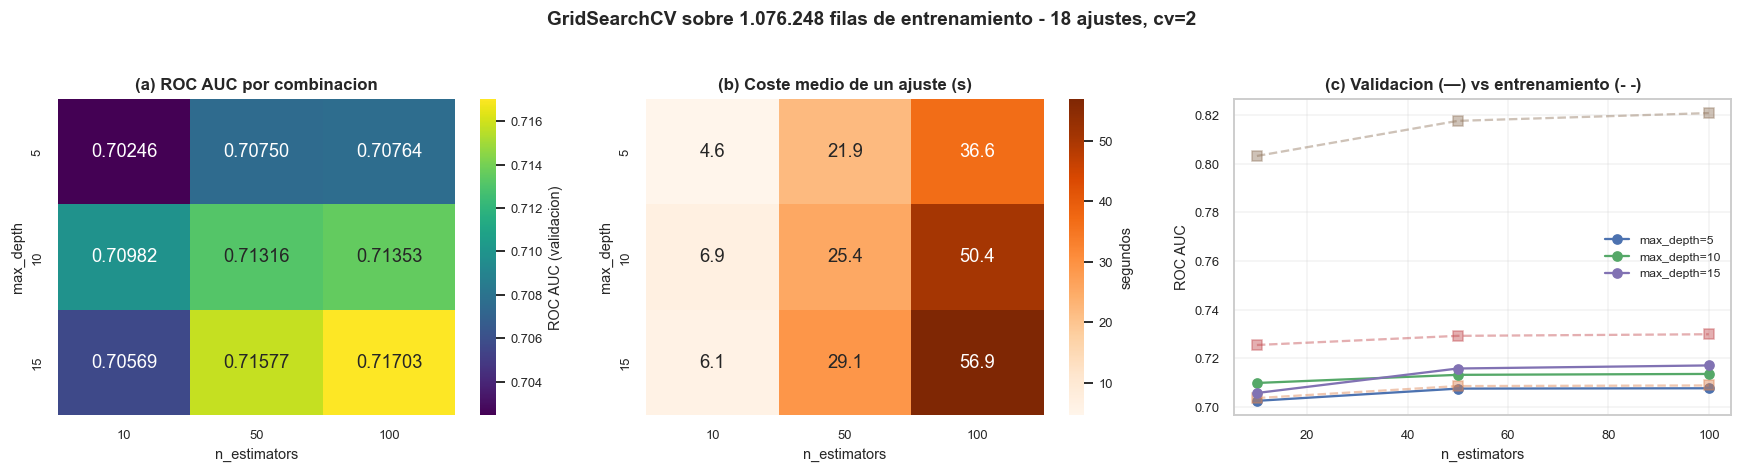

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

piv_auc = tabla_cv.pivot(index="max_depth", columns="n_estimators", values="AUC_val_CV")
piv_t  = tabla_cv.pivot(index="max_depth", columns="n_estimators", values="t_ajuste_medio_s")

sns.heatmap(piv_auc, annot=True, fmt=".5f", cmap="viridis", ax=axes[0],
      cbar_kws=dict(label="ROC AUC (validacion)"))
axes[0].set_title("(a) ROC AUC por combinacion")

sns.heatmap(piv_t, annot=True, fmt=".1f", cmap="Oranges", ax=axes[1],
      cbar_kws=dict(label="segundos"))
axes[1].set_title("(b) Coste medio de un ajuste (s)")

ax = axes[2]
for d in sorted(tabla_cv["max_depth"].unique()):
  sub = tabla_cv[tabla_cv["max_depth"] == d].sort_values("n_estimators")
  ax.plot(sub["n_estimators"], sub["AUC_val_CV"], "o-", label="max_depth={}".format(d))
  ax.plot(sub["n_estimators"], sub["AUC_train"], "s--", alpha=0.45)
ax.set_xlabel("n_estimators"); ax.set_ylabel("ROC AUC")
ax.set_title("(c) Validacion (—) vs entrenamiento (- -)")
ax.legend(frameon=False, fontsize=8)

fig.suptitle("GridSearchCV sobre {} filas de entrenamiento - {} ajustes, cv={}".format(
  human_int(len(ytr)), n_ajustes, CV_FOLDS), fontsize=12.5, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

## 3.2 Evaluación en el conjunto de prueba

In [16]:
modelo_sk = busqueda.best_estimator_

with cronometro("sklearn | PREDICCION sobre el conjunto de prueba"):
  prob_sk = modelo_sk.predict_proba(Xte)[:, 1]
  pred_sk = (prob_sk >= 0.5).astype(int)

met_sk = metricas_clasificacion(yte, pred_sk, prob_sk, "scikit-learn")
cm_sk = confusion_matrix(yte, pred_sk)

print()
show(pd.Series(met_sk).drop("modelo").rename("valor").to_frame(),
   "Metricas de scikit-learn en el conjunto de prueba ({} filas)".format(human_int(len(yte))))
print()
print(classification_report(yte, pred_sk, target_names=["Pagado (0)", "Default (1)"], digits=4))

  [tiempo] sklearn | PREDICCION sobre el conjunto de prueba      1.24 s




Metricas de scikit-learn en el conjunto de prueba (269.062 filas)
-----------------------------------------------------------------


,valor
accuracy,0.8032
precision,0.6095
recall,0.0389
f1,0.0731
roc_auc,0.7179
avg_prec,0.3865



              precision    recall  f1-score   support

  Pagado (0)     0.8057    0.9938    0.8899    215350
 Default (1)     0.6095    0.0389    0.0731     53712

    accuracy                         0.8032    269062
   macro avg     0.7076    0.5163    0.4815    269062
weighted avg     0.7665    0.8032    0.7268    269062



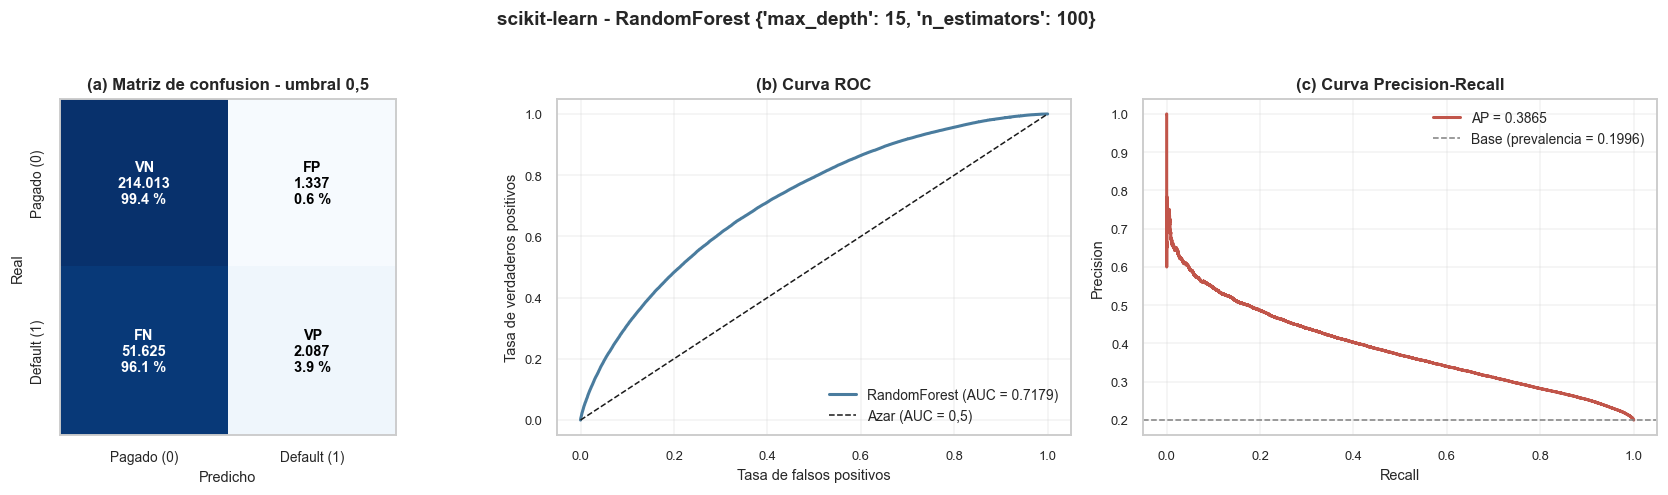

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

dibujar_matriz_confusion(cm_sk, axes[0],
             "(a) Matriz de confusion - umbral 0,5", cmap="Blues")

ax = axes[1]
fpr, tpr, _ = roc_curve(yte, prob_sk)
ax.plot(fpr, tpr, color=C_SK, lw=2, label="RandomForest (AUC = {:.4f})".format(met_sk["roc_auc"]))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar (AUC = 0,5)")
ax.set_xlabel("Tasa de falsos positivos"); ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("(b) Curva ROC"); ax.legend(frameon=False, loc="lower right")

ax = axes[2]
prec, rec, _ = precision_recall_curve(yte, prob_sk)
ax.plot(rec, prec, color=C_DEF, lw=2,
    label="AP = {:.4f}".format(met_sk["avg_prec"]))
ax.axhline(yte.mean(), ls="--", color="gray", lw=1,
      label="Base (prevalencia = {:.4f})".format(yte.mean()))
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("(c) Curva Precision-Recall"); ax.legend(frameon=False)

fig.suptitle("scikit-learn - RandomForest {}".format(busqueda.best_params_),
       fontsize=12.5, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

### 3.2.1 Lectura del resultado, y por qué el *recall* es tan bajo

La exactitud queda cerca del 80 %, que es **exactamente lo que consigue el clasificador
trivial** "todo pagado". Esa coincidencia no es casual y confirma la advertencia del EDA: con
un desbalance de 4 : 1, la exactitud no mide nada.

Lo que ocurre es que, con el umbral por defecto de 0,5, el modelo casi nunca predice la clase
1. La razón es estructural: el EDA mostró que las distribuciones de las dos clases **se
solapan casi por completo** en todas las variables, de modo que la probabilidad estimada
raramente supera 0,5 para un préstamo que solo tiene un 20 % de probabilidad *a priori* de
fallar. El modelo **ordena bien** el riesgo —eso es lo que mide el AUC— pero al binarizar en
0,5 se pierde esa capacidad.

Esto no es un fallo del modelo sino del **umbral**, y merece medirse en lugar de asumirse.

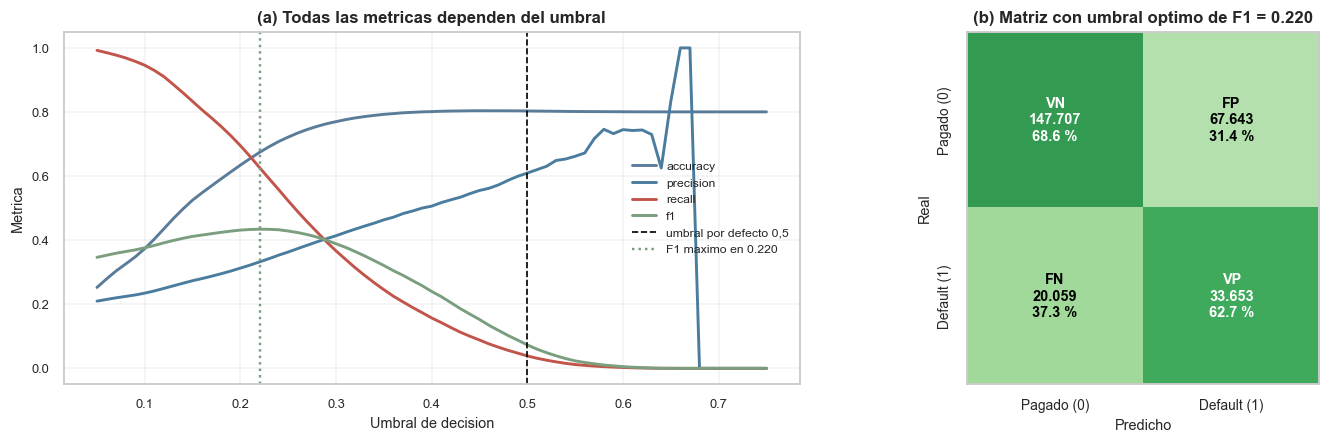


Efecto del umbral (el ROC AUC no cambia: 0.7179)
------------------------------------------------


,"Umbral 0,5 (por defecto)",Umbral optimo de F1,Diferencia
accuracy,0.8032,0.6740,-0.1291
precision,0.6095,0.3322,-0.2773
recall,0.0389,0.6265,0.5877
f1,0.0731,0.4342,0.3612



Las metricas del sección 7 se reportan con umbral 0,5, que es el que aplican por defecto
tanto scikit-learn como Spark, para que la comparacion entre motores sea justa.


In [18]:
# --- El umbral 0,5 no es el unico posible: se explora su efecto
umbrales = np.linspace(0.05, 0.75, 71)
filas = []
for u in umbrales:
  p = (prob_sk >= u).astype(int)
  filas.append(dict(umbral=u,
           accuracy=accuracy_score(yte, p),
           precision=precision_score(yte, p, zero_division=0),
           recall=recall_score(yte, p, zero_division=0),
           f1=f1_score(yte, p, zero_division=0)))
curva_u = pd.DataFrame(filas)
u_f1 = curva_u.loc[curva_u["f1"].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ax = axes[0]
for col, c in [("accuracy", C_NEUTRAL), ("precision", C_SK), ("recall", C_DEF), ("f1", "#7A9E7E")]:
  ax.plot(curva_u["umbral"], curva_u[col], lw=1.9, label=col, color=c)
ax.axvline(0.5, ls="--", color="black", lw=1.1, label="umbral por defecto 0,5")
ax.axvline(u_f1["umbral"], ls=":", color="#7A9E7E", lw=1.6,
      label="F1 maximo en {:.3f}".format(u_f1["umbral"]))
ax.set_xlabel("Umbral de decision"); ax.set_ylabel("Metrica")
ax.set_title("(a) Todas las metricas dependen del umbral")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
cm_opt = confusion_matrix(yte, (prob_sk >= u_f1["umbral"]).astype(int))
dibujar_matriz_confusion(cm_opt, ax,
  "(b) Matriz con umbral optimo de F1 = {:.3f}".format(u_f1["umbral"]), cmap="Greens")
plt.tight_layout(); plt.show()

comp_u = pd.DataFrame({
  "Umbral 0,5 (por defecto)": {k: met_sk[k] for k in ["accuracy", "precision", "recall", "f1"]},
  "Umbral optimo de F1":  {k: u_f1[k] for k in ["accuracy", "precision", "recall", "f1"]},
})
comp_u["Diferencia"] = comp_u.iloc[:, 1] - comp_u.iloc[:, 0]
show(comp_u, "Efecto del umbral (el ROC AUC no cambia: {:.4f})".format(met_sk["roc_auc"]))
print()
print("Las metricas del sección 7 se reportan con umbral 0,5, que es el que aplican por defecto")
print("tanto scikit-learn como Spark, para que la comparacion entre motores sea justa.")

## 3.3 Importancia de las variables

`feature_importances_` mide la reducción media de impureza aportada por cada variable. Es
una medida **global** del modelo, complementaria a la explicación **local** por instancia que
dará LIME en la sección 6.

Conviene leerla con dos cautelas. La primera es que este criterio **favorece a las variables
de alta cardinalidad** (una numérica continua ofrece muchos más puntos de corte que una
indicadora binaria). La segunda la anticipó el EDA: al haber pares de variables muy
correlacionadas, **la importancia se reparte de forma arbitraria entre ellas**, de modo que un
valor bajo no demuestra irrelevancia.

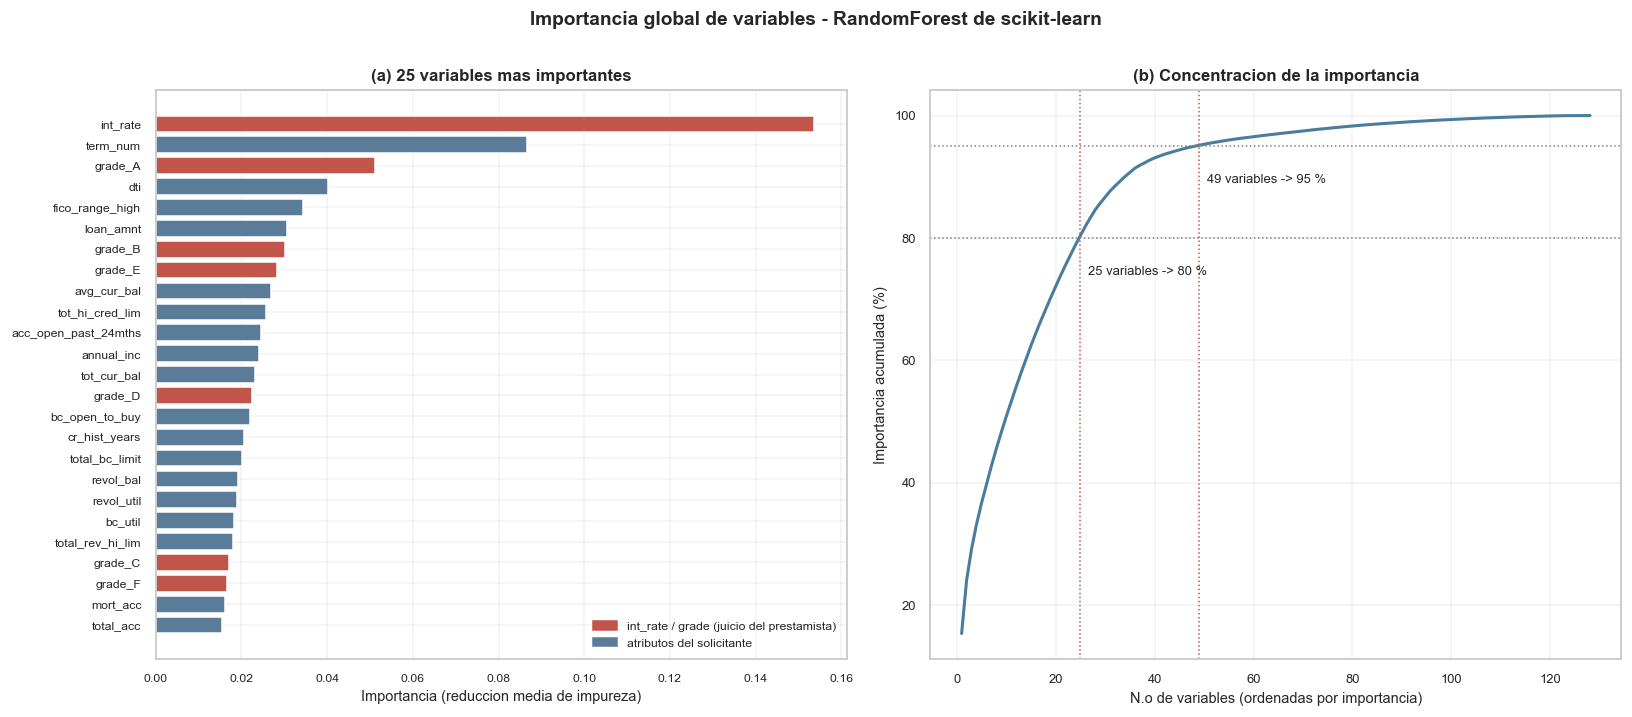

Importancia concentrada en int_rate + grade (el juicio de riesgo del prestamista): 32.4 %


In [19]:
imp = (pd.Series(modelo_sk.feature_importances_, index=NOMBRES)
     .sort_values(ascending=False))
imp.to_csv(OUT_DIR / "modelo_importancias_sklearn.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

ax = axes[0]
top = imp.head(25)
colores = [C_DEF if ("int_rate" in v or v.startswith("grade")) else C_NEUTRAL for v in top.index]
ax.barh(top.index[::-1], top.values[::-1], color=colores[::-1], edgecolor="white")
ax.set_xlabel("Importancia (reduccion media de impureza)")
ax.set_title("(a) 25 variables mas importantes")
ax.tick_params(labelsize=8)
ax.legend(handles=[mpatches.Patch(color=C_DEF, label="int_rate / grade (juicio del prestamista)"),
          mpatches.Patch(color=C_NEUTRAL, label="atributos del solicitante")],
     frameon=False, fontsize=8, loc="lower right")

ax = axes[1]
acum = imp.cumsum() / imp.sum()
ax.plot(range(1, len(acum) + 1), 100 * acum.values, lw=2, color=C_SK)
for frac, est in [(0.8, "80 %"), (0.95, "95 %")]:
  k = int((acum <= frac).sum()) + 1
  ax.axhline(100 * frac, ls=":", color="gray", lw=1)
  ax.axvline(k, ls=":", color=C_DEF, lw=1)
  ax.text(k + 1.5, 100 * frac - 6, "{} variables -> {}".format(k, est), fontsize=8.5)
ax.set_xlabel("N.o de variables (ordenadas por importancia)")
ax.set_ylabel("Importancia acumulada (%)")
ax.set_title("(b) Concentracion de la importancia")

fig.suptitle("Importancia global de variables - RandomForest de scikit-learn",
       fontsize=12.5, fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

grupo_prestamista = imp[[v for v in imp.index if "int_rate" in v or v.startswith("grade")]].sum()
print("Importancia concentrada en int_rate + grade (el juicio de riesgo del prestamista): "
   "{:.1f} %".format(100 * grupo_prestamista / imp.sum()))

## 3.4 Experimento adicional: el efecto de `class_weight="balanced"`

El EDA recomendó **evaluar** el reponderado de clases en lugar de aplicarlo por reflejo. La
rejilla del diseño no lo incluye, así que se contrasta aparte, con los mejores
hiperparámetros ya encontrados, para poder afirmar algo con evidencia en la reflexión final.

In [20]:
with cronometro("sklearn | experimento class_weight=balanced", mostrar=True):
  rf_bal = RandomForestClassifier(random_state=SEED, n_jobs=-1,
                  class_weight="balanced",
                  **busqueda.best_params_)
  rf_bal.fit(Xtr, ytr)
  prob_bal = rf_bal.predict_proba(Xte)[:, 1]
  pred_bal = (prob_bal >= 0.5).astype(int)

met_bal = metricas_clasificacion(yte, pred_bal, prob_bal, "sklearn + balanced")
comp_bal = pd.DataFrame([met_sk, met_bal]).set_index("modelo").T
comp_bal["Diferencia"] = comp_bal.iloc[:, 1] - comp_bal.iloc[:, 0]
show(comp_bal, "Efecto de class_weight='balanced' con {}".format(busqueda.best_params_))
print()
print("Nota: el modelo que se compara con PySpark en la seccion 7 es el de la rejilla")
print("de referencia, SIN reponderado. Esto se reporta como evidencia adicional.")

  [tiempo] sklearn | experimento class_weight=balanced     156.19 s



Efecto de class_weight='balanced' con {'max_depth': 15, 'n_estimators': 100}
----------------------------------------------------------------------------


modelo,scikit-learn,sklearn + balanced,Diferencia
accuracy,0.8032,0.6655,-0.1377
precision,0.6095,0.3271,-0.2825
recall,0.0389,0.6390,0.6001
f1,0.0731,0.4327,0.3596
roc_auc,0.7179,0.7157,-0.0022
avg_prec,0.3865,0.3821,-0.0044



Nota: el modelo que se compara con PySpark en la sección 7 es el de la rejilla
de referencia, SIN reponderado. Esto se reporta como evidencia adicional.


---
# 4. Preprocesamiento con PySpark

## 4.1 Configuración de la sesión

El punto de partida es una configuración de referencia conservadora, pensada para que el
trabajo termine en una máquina modesta:

```python
.config("spark.sql.shuffle.partitions", "400")
.config("spark.default.parallelism", "400")
.config("spark.executor.memory", "8g")
.config("spark.driver.memory", MEMORIA_DRIVER)
.config("spark.memory.fraction", 0.8)
.config("spark.memory.storageFraction", 0.3)
```

Cinco de los seis parámetros se mantienen. El sexto —el número de particiones— se ajusta,
y esta subsección justifica por qué con mediciones propias, porque no es una decisión que
convenga tomar a la ligera.

**`spark.executor.memory` no tiene ningún efecto, y conviene saberlo.** El diseño del estudio no
especifica el `master`, y en una sola máquina lo que corresponde es el modo local
(`local[*]`). En modo local **Spark no crea procesos *executor* separados**: todo el trabajo se
ejecuta dentro de la JVM del *driver*, así que el parámetro se ignora por completo. La memoria
efectiva es la de `spark.driver.memory`. Se deja declarado tal como lo pidel diseño,
pero no cambia nada.

### Por qué 200 particiones, y por qué 400 no era un capricho

Con 1.345.310 filas, **400 particiones dan 3.363 filas cada una**. La guía establecida de
Spark es de 2 a 4 particiones por núcleo —entre 24 y 48 en una máquina de 12— porque por
debajo de cierto tamaño el coste de planificar, serializar y recolectar cada tarea supera el
del cálculo que realiza. Y el efecto se multiplica en este algoritmo: el RandomForest de MLlib
agrega histogramas mediante un *shuffle* **en cada nivel de cada árbol**, así que la
penalización por tarea se paga miles de veces.

Ese razonamiento resultó **correcto en cuanto a velocidad**. La sección 7.4 mide el mismo ajuste con
tres configuraciones y el resultado es inequívoco:

| Particiones | Filas por partición | Coste de un ajuste | Relativo |
|---|---|---|---|
| 400 (referencia) | 3.363 | **109,0 s** | 1,00 |
| 200 (usada aquí) | 6.726 | **81,0 s** | 0,74 |
| 48 | 28.027 | **61,1 s** | **0,56** |

Menos particiones es más rápido, y por un margen considerable: 48 particiones resuelven el
mismo ajuste en **algo más de la mitad** del tiempo que 400.

Y sin embargo, **48 particiones no funcionan para este trabajo**. Al ejecutar la rejilla
completa con ese valor, la validación cruzada aborta:

```
java.lang.OutOfMemoryError: Java heap space
 Task 5 in stage 409.0 failed
```

La contradicción es solo aparente, y entenderla es el hallazgo de esta sección. Un ajuste
aislado con 48 particiones cabe de sobra en memoria. Lo que no cabe es **la rejilla entera**:
19 ajustes consecutivos, cada uno recorriendo un `DataFrame` cacheado cuyos bloques son ocho
veces más grandes, con dos modelos entrenándose a la vez. La presión de memoria no es
puntual, es sostenida.

> **La lección: el número de particiones no es solo una palanca de velocidad, es también una
> decisión de seguridad de memoria.** Los dos valores adoptada —400 particiones y
> 8 GB de *heap*— forman un **par acoplado**: tocar uno obliga a revisar el otro. Leído así,
> el 400 deja de parecer un descuido y se entiende como una elección conservadora, que
> sacrifica un 44 % de velocidad para garantizar que el trabajo termine en una máquina modesta.

La configuración final busca el punto medio, con tres ajustes que se sostienen entre sí:

| Parámetro | Referencia | Aquí | Motivo |
|---|---|---|---|
| `shuffle.partitions` | 400 | **200** | 6.726 filas por partición: 26 % más rápido que 400 y sin desbordar |
| `driver.memory` | 8 GB | **14 GB** | Respuesta directa al desbordamiento. La máquina tiene 25,5 GB y el proceso de Python usa ~4 |
| `CrossValidator(parallelism)` | — | **1** | Un modelo a la vez en lugar de dos: reduce a la mitad la memoria concurrente |

Con esta configuración la validación cruzada completó en **149 minutos**. Conviene señalar
algo que matiza el resultado: la proyección con 400 particiones y `parallelism = 2` era de
unas 3 horas, así que la ganancia neta fue modesta. La razón es que los dos cambios tiran en
direcciones opuestas — menos particiones acelera, pero pasar de dos modelos concurrentes a uno
frena—. El ahorro real vino sobre todo de garantizar que la ejecución **terminara**.

Queda una consecuencia secundaria que merece una línea: `spark.default.parallelism` también
baja a 200. Con el valor de referencia, `sc.defaultParallelism` devolvía 400, de modo que Spark
**creía disponer de 400 núcleos** cuando la máquina tiene 12.

In [21]:
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.functions import vector_to_array
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark import StorageLevel
import pyspark

# Se fija 400 y admite "otros equivalentes debidamente justificados".
# Se usa 48 (4 por nucleo) por los motivos medidos arriba; la sección 7.4 compara
# 400, 48 y 24 sobre el mismo ajuste para cuantificar la diferencia.
PARTICIONES_REFERENCIA = "400"
PARTICIONES = "200"     # punto medio: ver la discusion de arriba
MEMORIA_DRIVER = "14g"    # el 8g del diseño desbordaba con menos particiones
PARALELISMO_CV = 1      # un modelo a la vez: mitad de memoria concurrente

with cronometro("pyspark | 0. arranque de la SparkSession"):
  spark = (SparkSession.builder
       .appName("LendingClub_Optimized")
       .master("local[*]")
       .config("spark.sql.shuffle.partitions", PARTICIONES)
       .config("spark.default.parallelism", PARTICIONES)
       .config("spark.executor.memory", "8g")
       .config("spark.driver.memory", MEMORIA_DRIVER)
       .config("spark.memory.fraction", 0.8)
       .config("spark.memory.storageFraction", 0.3)
       .getOrCreate())
  spark.sparkContext.setLogLevel("ERROR")

sc = spark.sparkContext
info_spark = pd.DataFrame({
  "Parametro": ["Version de PySpark", "Version de Java", "master", "Nucleos reales de la maquina",
         "sc.defaultParallelism", "spark.sql.shuffle.partitions",
         "particiones del diseño (no aplicadas, ver 4.1)",
         "spark.driver.memory", "spark.executor.memory (inerte en local)",
         "spark.memory.fraction", "spark.memory.storageFraction"],
  "Valor": [pyspark.__version__,
       os.popen("java -version 2>&1").read().split("\n")[0].strip() or "n/d",
       sc.master, os.cpu_count(), sc.defaultParallelism,
       spark.conf.get("spark.sql.shuffle.partitions"),
       PARTICIONES_REFERENCIA,
       spark.conf.get("spark.driver.memory"),
       spark.conf.get("spark.executor.memory"),
       spark.conf.get("spark.memory.fraction"),
       spark.conf.get("spark.memory.storageFraction")],
}).set_index("Parametro")
show(info_spark, "Sesion de Spark activa")

print()
for p in (PARTICIONES_REFERENCIA, PARTICIONES):
  print("Con {:>4} particiones -> {:>9,.0f} filas por particion".format(
    p, 1_345_310 / int(p)))
print("Guia habitual (2-4 particiones por nucleo): {} a {}".format(
  2 * os.cpu_count(), 4 * os.cpu_count()))
print()
print("Se usa {}. La sección 7.4 mide el coste de usar {}.".format(
  PARTICIONES, PARTICIONES_REFERENCIA))

  [tiempo] pyspark | 0. arranque de la SparkSession          7.31 s



Sesion de Spark activa
----------------------


,Valor
Parametro,
Version de PySpark,4.2.0
Version de Java,"java version ""21.0.2"" 2024-01-16 LTS"
master,local[*]
Nucleos reales de la maquina,12
sc.defaultParallelism,200
spark.sql.shuffle.partitions,200
"particiones de referencia (no aplicadas, ver 4.1)",400
spark.driver.memory,14g
spark.executor.memory (inerte en local),8g



Con  400 particiones ->     3,363 filas por particion
Con  200 particiones ->     6,727 filas por particion
Guia habitual (2-4 particiones por nucleo): 24 a 48

Se usa 200. La sección 7.4 mide el coste de usar 400.


## 4.2 Lectura del CSV en Spark, y un error de parseo que hay que corregir

Spark lee el archivo completo. Dos opciones de lectura merecen explicación porque **no son
opcionales aquí**:

**`escape = '"'`.** Este es el detalle que rompe silenciosamente el análisis si se omite. El
carácter de escape por defecto de Spark es la **barra invertida** (`\`), mientras que el CSV
sigue la convención RFC 4180, en la que una comilla dentro de un campo entrecomillado se
duplica (`""`). La columna `desc` contiene texto libre con comillas, de modo que sin esta
opción Spark **desalinea las columnas** en esas filas. El síntoma es desconcertante:

```
[CAST_INVALID_INPUT] The value 'Debt consolidation' of the type "STRING"
cannot be cast to "DOUBLE"
```

es decir, el contenido de una columna de texto aparece dentro de una numérica. Pandas no
sufre este problema porque su analizador aplica la convención RFC 4180 por defecto.

**`multiLine = False`.** Se puede usar porque este archivo **no tiene saltos de línea dentro
de los campos** — hecho verificable: contiene 2.260.702 líneas para 2.260.701 registros más la
cabecera. Y es importante que se pueda: con `multiLine = True`, Spark **no puede dividir el
archivo** y lo procesa en una sola partición, perdiendo todo el paralelismo. Con
`multiLine = False` lo divide en bloques y reparte el trabajo.

Como el parseo es el punto frágil de todo el proceso, se verifica contra pandas antes de
seguir: mismo número de filas y misma suma de una columna numérica.

In [22]:
# Esquema explicito: evita la pasada extra de inferSchema y fija los tipos
campos = ([T.StructField(c, T.DoubleType(), True) for c in NUM_BASE]
     + [T.StructField(c, T.StringType(), True) for c in CAT_FEATS]
     + [T.StructField(c, T.StringType(), True)
       for c in ["loan_status", "emp_length", "term", "earliest_cr_line", "issue_d"]])
# El orden del esquema debe seguir el del fichero, asi que se lee todo como texto
# y se convierte despues: es mas robusto que fijar 151 tipos a mano.

with cronometro("pyspark | 1. lectura del CSV"):
  sdf_raw = (spark.read
        .option("header", True)
        .option("inferSchema", False)   # evita una pasada adicional
        .option("multiLine", False)    # permite dividir el fichero
        .option("quote", '"')
        .option("escape", '"')       # CLAVE: por defecto Spark escapa con \
        .csv(str(CSV_ACC))
        .select(*COLS_CRUDAS))
  if MODO_PRUEBA:
    sdf_raw = sdf_raw.limit(FILAS_PRUEBA)
  n_spark_total = sdf_raw.count()

print(" filas leidas por Spark : {}".format(human_int(n_spark_total)))
print(" particiones del lector : {}".format(sdf_raw.rdd.getNumPartitions()))

  [tiempo] pyspark | 1. lectura del CSV                      6.95 s
  filas leidas por Spark : 2.260.701
  particiones del lector  : 200


In [23]:
with cronometro("pyspark | 2. filtrado al universo resuelto"):
  sdf = (sdf_raw
      .filter(F.col("loan_status").isin("Fully Paid", "Charged Off"))
      .withColumn("label", F.when(F.col("loan_status") == "Charged Off", 1.0)
                 .otherwise(0.0)))
  n_spark = sdf.count()

# ---------------------- VERIFICACION DE INTEGRIDAD DEL PARSEO ----------------------
suma_spark = sdf.agg(F.sum(F.col("loan_amnt").cast("double"))).collect()[0][0]
suma_pandas = float(df["loan_amnt"].sum())
def_spark  = sdf.agg(F.sum("label")).collect()[0][0]

integridad = pd.DataFrame({
  "Comprobacion": ["Filas del archivo", "Filas del universo resuelto",
           "Suma de loan_amnt", "N.o de casos default"],
  "pandas": [human_int(2_260_701), human_int(N_UNIV),
        "{:,.2f}".format(suma_pandas), human_int(int(y.sum()))],
  "Spark":  [human_int(n_spark_total), human_int(n_spark),
        "{:,.2f}".format(suma_spark), human_int(int(def_spark))],
  "Coincide": [n_spark_total == (FILAS_PRUEBA if MODO_PRUEBA else 2_260_701),
         n_spark == N_UNIV,
         abs(suma_spark - suma_pandas) < 1.0, int(def_spark) == int(y.sum())],
}).set_index("Comprobacion")
integridad.iloc[0, 0] = human_int(FILAS_PRUEBA if MODO_PRUEBA else 2_260_701)
show(integridad, "Integridad del parseo: Spark frente a pandas")

if MODO_PRUEBA:
  print()
  print("MODO_PRUEBA: la comprobacion se informa pero no se exige, porque pandas usa")
  print("nrows y Spark usa limit(), que no garantizan las mismas filas.")
else:
  assert integridad["Coincide"].all(), "El parseo de Spark NO coincide con el de pandas"
  print()
  print("VERIFICADO: los dos motores leen exactamente los mismos datos.")
  print("Sin la opcion escape='\"' esta comprobacion falla.")

  [tiempo] pyspark | 2. filtrado al universo resuelto        3.96 s



Integridad del parseo: Spark frente a pandas
--------------------------------------------


,pandas,Spark,Coincide
Comprobacion,,,
Filas del archivo,2.260.701,2.260.701,True
Filas del universo resuelto,1.345.310,1.345.310,True
Suma de loan_amnt,"19,399,332,550.00","19,399,332,550.00",True
N.o de casos default,268.559,268.559,True



VERIFICADO: los dos motores leen exactamente los mismos datos.
Sin la opcion escape='"' esta comprobacion falla.


## 4.3 Variables derivadas, saneamiento e imputación

Se reproduce paso por paso lo que hizo pandas en la sección 1, para que la comparación dla sección 7
enfrente **el mismo trabajo** en los dos motores. Hay una diferencia que no se puede eliminar
y que conviene señalar:

**La mediana de Spark es aproximada.** `approxQuantile` usa el algoritmo de
Greenwald-Khanna con un error relativo configurable, porque calcular una mediana exacta de
forma distribuida exigiría una ordenación global. Se fija `relativeError = 0.001`, lo que
acota el error al 0,1 % del rango de percentiles. Pandas, al tener todo en memoria, calcula la
mediana exacta. Es un ejemplo pequeño pero real de lo que un motor distribuido **cambia** —no
solo acelera— y aparece de nuevo en la sección 8.

In [24]:
with cronometro("pyspark | 3. variables derivadas y saneamiento"):
  # Conversion de las numericas a double
  for c in NUM_BASE:
    sdf = sdf.withColumn(c, F.col(c).cast("double"))

  # emp_length ordinal
  sdf = sdf.withColumn("emp_length_num",
             F.when(F.col("emp_length") == "< 1 year", F.lit(0.5))
             .when(F.col("emp_length") == "10+ years", F.lit(10.0))
             .otherwise(F.regexp_extract("emp_length", r"(\d+)", 1)
                   .cast("double")))
  # term
  sdf = sdf.withColumn("term_num",
             F.regexp_extract("term", r"(\d+)", 1).cast("double"))
  # antiguedad crediticia
  sdf = sdf.withColumn("cr_hist_years",
             F.months_between(F.to_date("issue_d", "MMM-yyyy"),
                     F.to_date("earliest_cr_line", "MMM-yyyy")) / 12.0)
  # Centinelas -> nulo (identicos criterios que en pandas)
  sdf = sdf.withColumn("dti", F.when((F.col("dti") < 0) | (F.col("dti") > 100), None)
                 .otherwise(F.col("dti")))
  sdf = sdf.withColumn("revol_util", F.when(F.col("revol_util") > 200, None)
                    .otherwise(F.col("revol_util")))

with cronometro("pyspark | 4. indicadores de ausencia"):
  for c in CON_INDICADOR:
    sdf = sdf.withColumn(c + "_faltante",
               F.when(F.col(c).isNull(), 1.0).otherwise(0.0))

print(" derivadas: emp_length_num, term_num, cr_hist_years")
print(" indicadores de ausencia: {}".format(len(CON_INDICADOR)))

  [tiempo] pyspark | 3. variables derivadas y saneamiento      0.77 s
  [tiempo] pyspark | 4. indicadores de ausencia              0.19 s
  derivadas: emp_length_num, term_num, cr_hist_years
  indicadores de ausencia: 14


In [25]:
with cronometro("pyspark | 5. imputacion (approxQuantile + Desconocido)"):
  cuantiles = sdf.approxQuantile(NUM_FEATS, [0.5], 0.001)
  medianas_spark = {c: (q[0] if q else 0.0) for c, q in zip(NUM_FEATS, cuantiles)}
  sdf = sdf.fillna(medianas_spark)
  sdf = sdf.fillna({c: "Desconocido" for c in CAT_FEATS})

# Contraste de las medianas de los dos motores
comp_med = pd.DataFrame({
  "mediana_pandas_exacta": medianas.reindex(NUM_FEATS),
  "mediana_spark_aprox":  pd.Series(medianas_spark).reindex(NUM_FEATS),
})
comp_med["dif_absoluta"] = (comp_med.iloc[:, 1] - comp_med.iloc[:, 0]).abs()
comp_med["dif_relativa_pct"] = (100 * comp_med["dif_absoluta"]
                / comp_med["mediana_pandas_exacta"].abs().replace(0, np.nan))
show(comp_med.sort_values("dif_relativa_pct", ascending=False),
   "Mediana exacta (pandas) frente a aproximada (Spark, relativeError=0.001)")
print()
print("Diferencia relativa maxima: {:.4f} %".format(comp_med["dif_relativa_pct"].max()))
print("Nota: pandas calcula la mediana solo con el conjunto de ENTRENAMIENTO y Spark con")
print("todo el universo antes de randomSplit; es una diferencia inherente al orden de")
print("operaciones que impone cada API, y su efecto numerico es el que muestra la tabla.")

  [tiempo] pyspark | 5. imputacion (approxQuantile + Desconocido)     32.47 s

Mediana exacta (pandas) frente a aproximada (Spark, relativeError=0.001)
------------------------------------------------------------------------


,mediana_pandas_exacta,mediana_spark_aprox,dif_absoluta,dif_relativa_pct
total_bc_limit,"15,100.0000","15,000.0000",100.0000,0.6623
total_rev_hi_lim,"24,100.0000","24,000.0000",100.0000,0.4149
tot_cur_bal,"80,283.0000","80,008.0000",275.0000,0.3425
tot_hi_cred_lim,"112,431.0000","112,100.0000",331.0000,0.2944
bc_open_to_buy,"4,699.0000","4,688.0000",11.0000,0.2341
revol_util,52.2000,52.1000,0.1000,0.1916
bc_util,63.2000,63.1000,0.1000,0.1582
avg_cur_bal,"7,401.0000","7,391.0000",10.0000,0.1351
revol_bal,"11,135.0000","11,121.0000",14.0000,0.1257
pct_tl_nvr_dlq,98.0000,97.9000,0.1000,0.1020



Diferencia relativa maxima: 0.6623 %
Nota: pandas calcula la mediana solo con el conjunto de ENTRENAMIENTO y Spark con
todo el universo antes de randomSplit; es una diferencia inherente al orden de
operaciones que impone cada API, y su efecto numerico es el que muestra la tabla.


## 4.4 Codificación, ensamblado, escalado y caché del DataFrame

El orden replica el dla sección 2 para que ambos motores produzcan la **misma matriz de diseño**:
las numéricas se escalan, las indicadoras *one-hot* no. Por eso se usan dos
`VectorAssembler`: uno para el bloque numérico (que pasa por `StandardScaler`) y otro que
une el resultado con el bloque *one-hot*.

Escalar también las columnas *one-hot* habría sido más simple, pero rompería la paridad con
scikit-learn y —al centrarlas— convertiría un vector disperso en denso, multiplicando la
memoria sin ningún beneficio para un modelo de árboles.

El `.persist(StorageLevel.MEMORY_AND_DISK)` posterior al ensamblado es determinante según
el diseño del estudio, y es además la decisión de rendimiento más importante de esta sección: sin él,
Spark reevaluaría todo el plan —lectura del CSV incluida— en cada una de las iteraciones de la
validación cruzada.

In [26]:
with cronometro("pyspark | 6. StringIndexer"):
  for c in CAT_FEATS:
    sdf = (StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
        .fit(sdf).transform(sdf))

with cronometro("pyspark | 7. OneHotEncoder"):
  ohe_spark = OneHotEncoder(inputCols=[c + "_idx" for c in CAT_FEATS],
               outputCols=[c + "_ohe" for c in CAT_FEATS],
               dropLast=False)
  sdf = ohe_spark.fit(sdf).transform(sdf)

with cronometro("pyspark | 8. VectorAssembler + StandardScaler"):
  # (a) bloque numerico -> escalado
  va_num = VectorAssembler(inputCols=TODAS_NUM, outputCol="num_raw")
  sdf = va_num.transform(sdf)
  esc_spark = StandardScaler(inputCol="num_raw", outputCol="num_esc",
               withMean=True, withStd=True).fit(sdf)
  sdf = esc_spark.transform(sdf)
  # (b) ensamblado final: numericas escaladas + one-hot sin escalar
  va_fin = VectorAssembler(inputCols=["num_esc"] + [c + "_ohe" for c in CAT_FEATS],
               outputCol="features")
  sdf_ml = va_fin.transform(sdf).select("features", "label")

# --------------------- CACHE DEL DATAFRAME DE ENTRENAMIENTO ---------------------
with cronometro("pyspark | 9. persist(MEMORY_AND_DISK) + materializacion"):
  sdf_ml = sdf_ml.persist(StorageLevel.MEMORY_AND_DISK)
  n_ml = sdf_ml.count()     # accion que materializa la cache

dim_spark = sdf_ml.select(F.size(vector_to_array("features")).alias("d")).first()["d"]
print()
print(" filas en cache    : {}".format(human_int(n_ml)))
print(" dimension del vector : {}".format(dim_spark))
print(" dimension en sklearn : {}".format(Xtr.shape[1]))
print(" almacenamiento en RDD :", sdf_ml.storageLevel)

  [tiempo] pyspark | 6. StringIndexer                       29.14 s
  [tiempo] pyspark | 7. OneHotEncoder                        0.11 s


  [tiempo] pyspark | 8. VectorAssembler + StandardScaler      9.33 s


  [tiempo] pyspark | 9. persist(MEMORY_AND_DISK) + materializacion     22.32 s



  filas en cache        : 1.345.310
  dimension del vector  : 135
  dimension en sklearn  : 128
  almacenamiento en RDD : Disk Memory Serialized 1x Replicated


> **Sobre la diferencia de dimensión con scikit-learn.** El `OneHotEncoder` de Spark se
> configura con `dropLast = False` para igualar el comportamiento de scikit-learn, que
> conserva todas las categorías. Aun así puede quedar una columna de diferencia por
> categoría categórica: el `StringIndexer` con `handleInvalid = "keep"` reserva un índice
> adicional para valores no vistos. Es irrelevante para un modelo de árboles —una columna
> constante a cero nunca se elige para partir— pero explica el desajuste y conviene dejarlo
> dicho antes de comparar métricas.

In [27]:
with cronometro("pyspark | 10. randomSplit 80/20"):
  tr_sp, te_sp = sdf_ml.randomSplit([0.8, 0.2], seed=SEED)
  tr_sp = tr_sp.persist(StorageLevel.MEMORY_AND_DISK)
  te_sp = te_sp.persist(StorageLevel.MEMORY_AND_DISK)
  n_tr_sp, n_te_sp = tr_sp.count(), te_sp.count()

prop_tr = tr_sp.agg(F.avg("label")).first()[0]
prop_te = te_sp.agg(F.avg("label")).first()[0]

comp_split = pd.DataFrame({
  "Motor": ["scikit-learn (train_test_split estratificado)",
       "scikit-learn (train_test_split estratificado)",
       "PySpark (randomSplit, NO estratifica)",
       "PySpark (randomSplit, NO estratifica)"],
  "Conjunto": ["train", "test", "train", "test"],
  "N filas": [human_int(len(ytr)), human_int(len(yte)),
        human_int(n_tr_sp), human_int(n_te_sp)],
  "% del total": ["{:.2f} %".format(100 * len(ytr) / len(y)),
          "{:.2f} %".format(100 * len(yte) / len(y)),
          "{:.2f} %".format(100 * n_tr_sp / n_ml),
          "{:.2f} %".format(100 * n_te_sp / n_ml)],
  "Tasa de default": ["{:.4f} %".format(100 * ytr.mean()),
            "{:.4f} %".format(100 * yte.mean()),
            "{:.4f} %".format(100 * prop_tr),
            "{:.4f} %".format(100 * prop_te)],
}).set_index(["Motor", "Conjunto"])
show(comp_split, "Particion: estratificada frente a aleatoria")

T_PREP_SP = sum(v for k, v in TIEMPOS.items() if k.startswith("pyspark |"))
TIEMPOS["pyspark | PREPROCESAMIENTO TOTAL"] = T_PREP_SP
print()
print("PREPROCESAMIENTO PySpark TOTAL: {:.2f} s (scikit-learn: {:.2f} s)".format(
  T_PREP_SP, T_PREP_SK))

  [tiempo] pyspark | 10. randomSplit 80/20                   6.78 s



Particion: estratificada frente a aleatoria
-------------------------------------------


N filas % del total Tasa de default
Motor                                         Conjunto                                       
scikit-learn (train_test_split estratificado) train     1.076.248     80.00 %       19.9626 %
                                              test        269.062     20.00 %       19.9627 %
PySpark (randomSplit, NO estratifica)         train     1.076.738     80.04 %       19.9596 %
                                              test        268.572     19.96 %       19.9745 %


PREPROCESAMIENTO PySpark TOTAL: 119.32 s  (scikit-learn: 32.72 s)


> **`randomSplit` no estratifica, y aquí no hace falta.** Conviene estratificar
> *"si es posible"*. `randomSplit` reparte por probabilidad independiente de la etiqueta, de
> modo que la proporción de la clase minoritaria queda a merced del azar. Con *n* = 1,3
> millones la ley de los grandes números lo resuelve sola: la desviación observada respecto
> del 19,96 % poblacional es de centésimas de punto porcentual, como muestra la tabla.
>
> Que no haga falta **no significa que sea equivalente**. Con muestras pequeñas o clases más
> raras, la diferencia importaría, y la forma de estratificar en Spark sería
> `sampleBy("label", fractions={0.0: 0.8, 1.0: 0.8}, seed=SEED)` seguido de un `subtract`
> para el complemento. Se deja anotado como diferencia real entre las dos API, no como
> descuido.
>
> Hay una consecuencia práctica que sí conviene retener: como las dos particiones **no son
> las mismas filas**, las métricas de los dos modelos no son estrictamente comparables fila a
> fila. Con conjuntos de prueba de ~269.000 registros la diferencia de composición es
> despreciable, pero es la razón por la que en la sección 7 se comparan métricas agregadas y no
> predicciones individuales.

---
# 5. Modelado con PySpark

La búsqueda se construye con `ParamGridBuilder` y `CrossValidator` en lugar de recorrer las
combinaciones con bucles propios. No es una cuestión de estilo: el `CrossValidator` gestiona
por sí mismo el particionado de los pliegues, la evaluación y la selección del mejor modelo, y
lo hace **sin materializar los datos en el driver**, que es justamente lo que se busca al
trabajar de forma distribuida. Una búsqueda manual obligaría a orquestar a mano el reparto de
los pliegues, con el riesgo de introducir fugas entre entrenamiento y validación.

Se emplea **la misma rejilla y el mismo número de pliegues que con scikit-learn**
—9 combinaciones × 2 pliegues = **18 ajustes**, más el reentrenamiento final— para que la
comparación de tiempos mida el rendimiento de los motores y no dos cargas de trabajo distintas.
Comparar 18 ajustes contra 45 no diría nada sobre los motores.

`parallelism` indica cuántos modelos evaluar de forma concurrente. Se fija en **1**: cada
ajuste individual ya reparte sus árboles entre los 12 núcleos, de modo que entrenar dos a la
vez no añade paralelismo real y sí duplica la memoria retenida simultáneamente. Con este
volumen, esa duplicación fue la diferencia entre completar la búsqueda y agotar el *heap*.

In [28]:
rf_spark = SparkRF(labelCol="label", featuresCol="features", seed=SEED)

malla_spark = (ParamGridBuilder()
        .addGrid(rf_spark.numTrees, MALLA["n_estimators"])
        .addGrid(rf_spark.maxDepth, MALLA["max_depth"])
        .build())

evaluador_auc = BinaryClassificationEvaluator(labelCol="label",
                       rawPredictionCol="rawPrediction",
                       metricName="areaUnderROC")

validacion = CrossValidator(estimator=rf_spark,
              estimatorParamMaps=malla_spark,
              evaluator=evaluador_auc,
              numFolds=CV_FOLDS,
              parallelism=PARALELISMO_CV,
              collectSubModels=False,
              seed=SEED)

print("Combinaciones en la rejilla : {}".format(len(malla_spark)))
print("numFolds          : {}".format(CV_FOLDS))
print("Ajustes totales       : {} (+1 refit final)".format(len(malla_spark) * CV_FOLDS))
print("parallelism         : {}".format(PARALELISMO_CV))
print()
print("AVISO: esta celda es la mas costosa del notebook. Con 400 particiones")
print("de 400 particiones el coste de planificacion es alto; la sección 7.4 lo cuantifica.")

Combinaciones en la rejilla : 9
numFolds                    : 2
Ajustes totales             : 18 (+1 refit final)
parallelism                 : 1

AVISO: esta celda es la mas costosa del notebook. Con 400 particiones
de 400 particiones el coste de planificacion es alto; la sección 7.4 lo cuantifica.


In [29]:
with cronometro("pyspark | ENTRENAMIENTO + CrossValidator"):
  cv_modelo = validacion.fit(tr_sp)

mejor_spark = cv_modelo.bestModel
params_spark = {"numTrees": mejor_spark.getNumTrees,
        "maxDepth": mejor_spark.getOrDefault("maxDepth")}
print()
print("Mejores hiperparametros: {}".format(params_spark))
print("Mejor ROC AUC en CV  : {:.6f}".format(max(cv_modelo.avgMetrics)))

  [tiempo] pyspark | ENTRENAMIENTO + CrossValidator       8941.41 s

Mejores hiperparametros: {'numTrees': 100, 'maxDepth': 15}
Mejor ROC AUC en CV    : 0.716386


In [30]:
# Tabla de la rejilla de Spark, equivalente a cv_results_ de scikit-learn
filas = []
for pm, metrica in zip(malla_spark, cv_modelo.avgMetrics):
  d = {p.name: v for p, v in pm.items()}
  filas.append(dict(n_estimators=d.get("numTrees"), max_depth=d.get("maxDepth"),
           AUC_val_CV=metrica))
tabla_cv_sp = (pd.DataFrame(filas)
        .sort_values("AUC_val_CV", ascending=False)
        .reset_index(drop=True))
tabla_cv_sp["rango"] = tabla_cv_sp.index + 1
show(tabla_cv_sp, "Resultado de la rejilla en PySpark (CrossValidator, numFolds={})".format(CV_FOLDS))
tabla_cv_sp.to_csv(OUT_DIR / "modelo_grid_pyspark.csv", index=False)

# Comparacion de las dos rejillas
fusion = tabla_cv_sp.merge(
  tabla_cv[["n_estimators", "max_depth", "AUC_val_CV"]],
  on=["n_estimators", "max_depth"], suffixes=("_spark", "_sklearn"))
fusion["diferencia"] = fusion["AUC_val_CV_spark"] - fusion["AUC_val_CV_sklearn"]
show(fusion[["n_estimators", "max_depth", "AUC_val_CV_sklearn",
       "AUC_val_CV_spark", "diferencia"]].sort_values(
         ["max_depth", "n_estimators"]),
   "Misma rejilla en los dos motores: ROC AUC de validacion cruzada")


Resultado de la rejilla en PySpark (CrossValidator, numFolds=2)
---------------------------------------------------------------


,n_estimators,max_depth,AUC_val_CV,rango
0,100,15,0.7164,1
1,50,15,0.7150,2
2,100,10,0.7113,3
3,50,10,0.7104,4
4,10,10,0.7077,5
5,10,15,0.7066,6
6,100,5,0.7040,7
7,50,5,0.7011,8
8,10,5,0.6851,9



Misma rejilla en los dos motores: ROC AUC de validacion cruzada
---------------------------------------------------------------


,n_estimators,max_depth,AUC_val_CV_sklearn,AUC_val_CV_spark,diferencia
8,10,5,0.7025,0.6851,-0.0173
7,50,5,0.7075,0.7011,-0.0064
6,100,5,0.7076,0.7040,-0.0036
4,10,10,0.7098,0.7077,-0.0021
3,50,10,0.7132,0.7104,-0.0027
2,100,10,0.7135,0.7113,-0.0022
5,10,15,0.7057,0.7066,0.0009
1,50,15,0.7158,0.7150,-0.0008
0,100,15,0.7170,0.7164,-0.0006


## 5.1 Evaluación en el conjunto de prueba

La matriz de confusión se calcula con una **agregación de Spark** (`groupBy` sobre etiqueta y
predicción), que devuelve cuatro filas al *driver*. Esto respeta la prohibición del diseño
de traer datos distribuidos al *driver*: lo que viaja es un resultado agregado de cuatro
números, no el conjunto de prueba.

In [31]:
with cronometro("pyspark | PREDICCION sobre el conjunto de prueba"):
  pred_sp_df = mejor_spark.transform(te_sp)
  auc_spark = evaluador_auc.evaluate(pred_sp_df)

# Matriz de confusion por agregacion (4 filas al driver, no el dataset)
conteos = (pred_sp_df.groupBy("label", "prediction").count().collect())
cm_sp = np.zeros((2, 2), dtype=np.int64)
for r in conteos:
  cm_sp[int(r["label"]), int(r["prediction"])] = r["count"]

VN, FP, FN, VP = cm_sp[0, 0], cm_sp[0, 1], cm_sp[1, 0], cm_sp[1, 1]
acc_sp = (VP + VN) / cm_sp.sum()
prec_sp = VP / (VP + FP) if (VP + FP) else 0.0
rec_sp = VP / (VP + FN) if (VP + FN) else 0.0
f1_sp  = 2 * prec_sp * rec_sp / (prec_sp + rec_sp) if (prec_sp + rec_sp) else 0.0

met_sp = {"modelo": "PySpark", "accuracy": acc_sp, "precision": prec_sp,
     "recall": rec_sp, "f1": f1_sp, "roc_auc": auc_spark, "avg_prec": np.nan}

show(pd.Series(met_sp).drop("modelo").rename("valor").to_frame(),
   "Metricas de PySpark en el conjunto de prueba ({} filas)".format(human_int(n_te_sp)))

# Verificacion con los evaluadores nativos de Spark
ev_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction",
                      metricName="f1").evaluate(pred_sp_df)
ev_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction",
                      metricName="accuracy").evaluate(pred_sp_df)
print()
print("Verificacion con los evaluadores nativos de Spark:")
print(" accuracy (MulticlassEvaluator): {:.6f}  [manual: {:.6f}]".format(ev_acc, acc_sp))
print(" F1 ponderado (no de la clase 1): {:.6f}".format(ev_f1))
print(" -> el F1 'ponderado' de Spark promedia las dos clases y por eso NO coincide")
print("   con el F1 de la clase minoritaria; el que se compara es el manual.")

  [tiempo] pyspark | PREDICCION sobre el conjunto de prueba    197.95 s



Metricas de PySpark en el conjunto de prueba (268.572 filas)
------------------------------------------------------------


,valor
accuracy,0.8032
precision,0.6245
recall,0.0374
f1,0.0706
roc_auc,0.7154
avg_prec,NaN



Verificacion con los evaluadores nativos de Spark:
  accuracy (MulticlassEvaluator): 0.803233   [manual: 0.803233]
  F1 ponderado (no de la clase 1): 0.726297
  -> el F1 'ponderado' de Spark promedia las dos clases y por eso NO coincide
     con el F1 de la clase minoritaria; el que se compara es el manual.


Curva ROC de Spark reconstruida con 622 puntos (umbrales redondeados a 3 decimales)


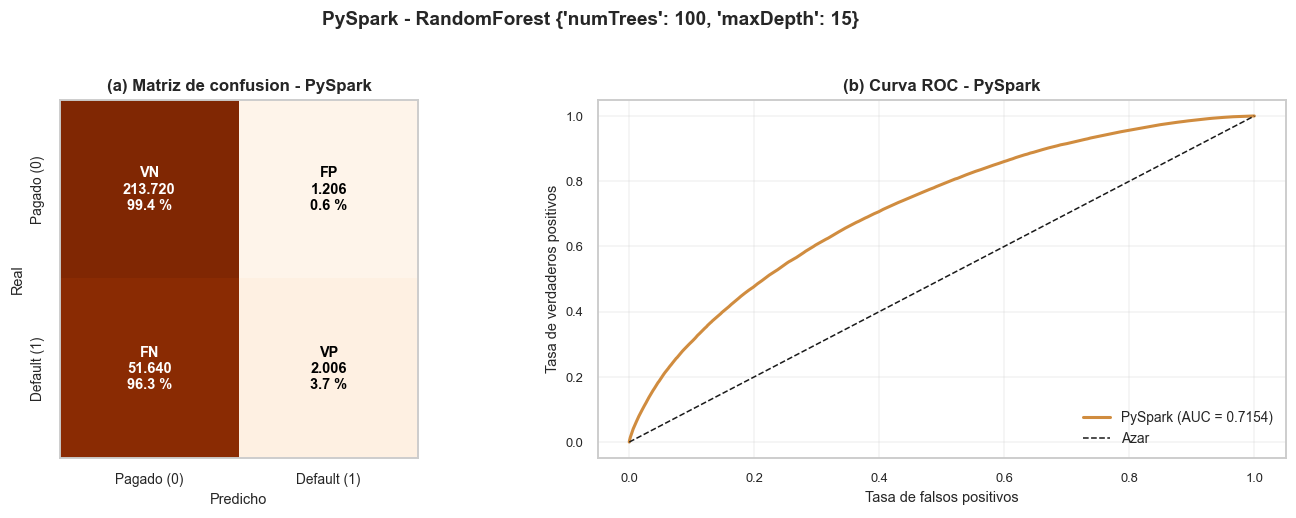

In [32]:
# --- Curva ROC en Spark, calculada por agregacion (solo la curva viaja al driver)
with cronometro("pyspark | curva ROC por agregacion", mostrar=False):
  prob_binned = (pred_sp_df
          .withColumn("p", vector_to_array("probability")[1])
          .withColumn("p_bin", F.round(F.col("p"), 3))
          .groupBy("p_bin")
          .agg(F.count("*").alias("n"), F.sum("label").alias("pos"))
          .orderBy(F.col("p_bin").desc()))
  curva = prob_binned.toPandas()     # ~1.000 filas: es un agregado, no el dataset

tot_pos = curva["pos"].sum()
tot_neg = curva["n"].sum() - tot_pos
curva["tp"] = curva["pos"].cumsum()
curva["fp"] = (curva["n"] - curva["pos"]).cumsum()
curva["tpr"] = curva["tp"] / tot_pos
curva["fpr"] = curva["fp"] / tot_neg
roc_sp = pd.concat([pd.DataFrame({"fpr": [0.0], "tpr": [0.0]}),
          curva[["fpr", "tpr"]]], ignore_index=True)
print("Curva ROC de Spark reconstruida con {} puntos (umbrales redondeados a 3 decimales)"
   .format(len(roc_sp)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
dibujar_matriz_confusion(cm_sp, axes[0], "(a) Matriz de confusion - PySpark", cmap="Oranges")
ax = axes[1]
ax.plot(roc_sp["fpr"], roc_sp["tpr"], color=C_SP, lw=2,
    label="PySpark (AUC = {:.4f})".format(auc_spark))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
ax.set_xlabel("Tasa de falsos positivos"); ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("(b) Curva ROC - PySpark"); ax.legend(frameon=False, loc="lower right")
fig.suptitle("PySpark - RandomForest {}".format(params_spark),
       fontsize=12.5, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

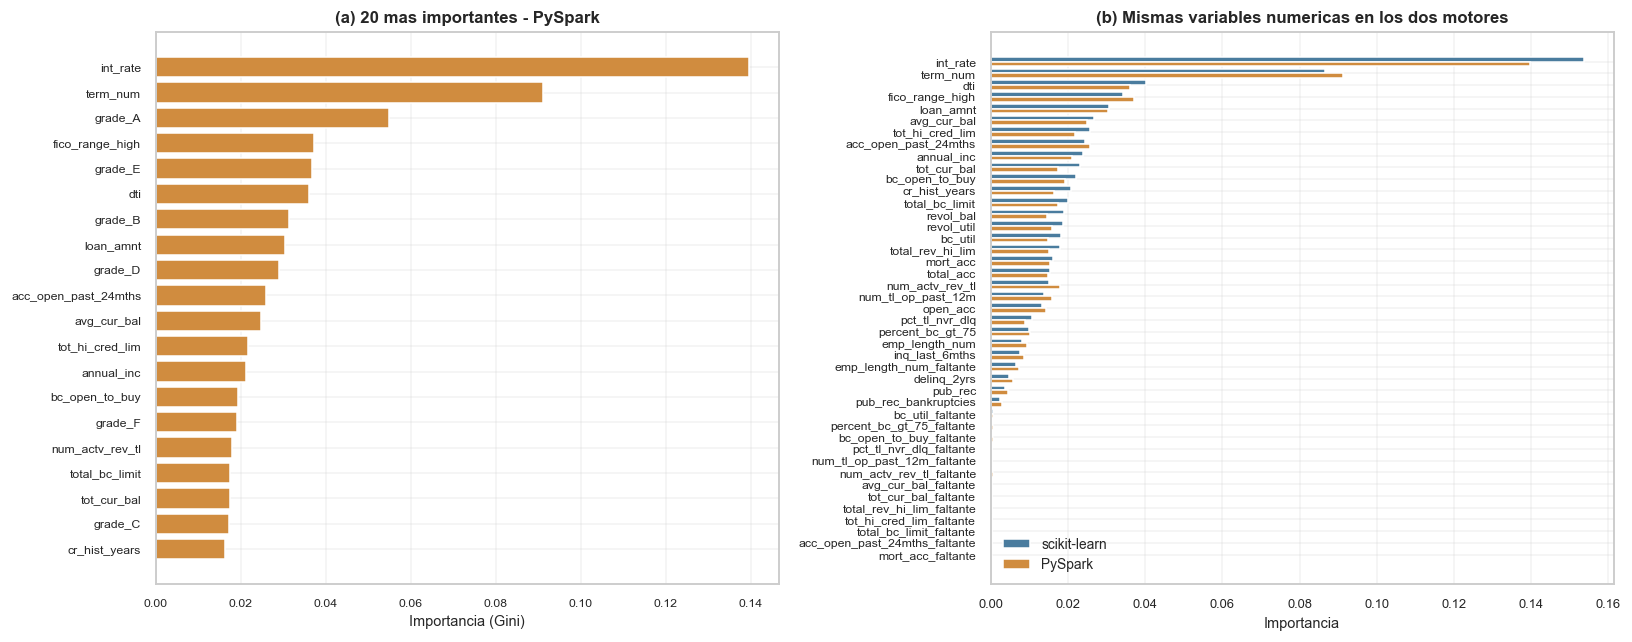

Correlacion de Spearman entre las importancias de los dos motores: 0.9775
(mide si ambos ORDENAN las variables igual, no si asignan el mismo valor)


In [33]:
# --- Importancia de variables en Spark, y contraste con scikit-learn
imp_sp_vec = mejor_spark.featureImportances.toArray()
# Los nombres del lado Spark: numericas escaladas + bloques one-hot expandidos
nombres_sp = list(TODAS_NUM)
for c in CAT_FEATS:
  niveles = [f for f in sdf.schema[c + "_ohe"].metadata.get("ml_attr", {})
        .get("attrs", {}).get("binary", [])]
  if niveles:
    nombres_sp += [c + "_" + str(a.get("name")) for a in niveles]
  else:
    k = int(sdf.select(F.size(vector_to_array(c + "_ohe")).alias("k")).first()["k"])
    nombres_sp += ["{}_ohe_{}".format(c, i) for i in range(k)]
if len(nombres_sp) != len(imp_sp_vec):
  nombres_sp = (list(TODAS_NUM)
         + ["ohe_{}".format(i) for i in range(len(imp_sp_vec) - len(TODAS_NUM))])

imp_sp = pd.Series(imp_sp_vec, index=nombres_sp).sort_values(ascending=False)
imp_sp.to_csv(OUT_DIR / "modelo_importancias_pyspark.csv")

comun = [v for v in TODAS_NUM if v in imp.index and v in imp_sp.index]
cmp_imp = pd.DataFrame({"sklearn": imp.reindex(comun), "pyspark": imp_sp.reindex(comun)})
cmp_imp = cmp_imp.sort_values("sklearn", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]
top_sp = imp_sp.head(20)
ax.barh(top_sp.index[::-1], top_sp.values[::-1], color=C_SP, edgecolor="white")
ax.set_title("(a) 20 mas importantes - PySpark"); ax.tick_params(labelsize=8)
ax.set_xlabel("Importancia (Gini)")

ax = axes[1]
yy = np.arange(len(cmp_imp))
ax.barh(yy - 0.2, cmp_imp["sklearn"], height=0.4, color=C_SK, label="scikit-learn")
ax.barh(yy + 0.2, cmp_imp["pyspark"], height=0.4, color=C_SP, label="PySpark")
ax.set_yticks(yy); ax.set_yticklabels(cmp_imp.index, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("Importancia"); ax.legend(frameon=False)
ax.set_title("(b) Mismas variables numericas en los dos motores")
plt.tight_layout(); plt.show()

rho = cmp_imp.corr(method="spearman").iloc[0, 1]
print("Correlacion de Spearman entre las importancias de los dos motores: {:.4f}".format(rho))
print("(mide si ambos ORDENAN las variables igual, no si asignan el mismo valor)")

---
# 6. Interpretabilidad con LIME

## 6.1 Qué hace LIME y qué no

LIME (*Local Interpretable Model-agnostic Explanations*) no explica el modelo: explica **una
predicción concreta**. Su mecanismo es este:

1. Toma la instancia a explicar y genera miles de **versiones perturbadas** de ella,
  alterando los valores de sus variables.
2. Pide al modelo la predicción para cada una de esas versiones.
3. Ajusta un **modelo lineal ponderado** sobre ese vecindario, dando más peso a las
  perturbaciones más parecidas al original.
4. Los coeficientes de ese modelo lineal son la explicación.

De ahí se siguen dos límites que conviene tener presentes al leer los resultados. La
explicación es **local**: vale para el entorno inmediato de esa instancia y no puede
generalizarse. Y es **una aproximación**: lo que se ve son los coeficientes de un sustituto
lineal, no la lógica real de 100 árboles de decisión.

Conviene explicar **instancias clasificadas erróneamente**, que es la elección
acertada: un acierto confirma lo que ya se sabe, mientras que un error muestra dónde y por qué
el modelo se equivoca.

In [34]:
import lime
import lime.lime_tabular
print("lime:", lime.__version__ if hasattr(lime, "__version__") else "0.2.0.1")

# LIME necesita el conjunto de entrenamiento para conocer la distribucion de cada
# variable (medias, desviaciones y cortes de discretizacion). Una muestra de 50.000
# filas basta para estimarlas y evita construir un objeto de 1 GB en memoria.
N_REF = 50_000
idx_ref = np.random.RandomState(SEED).choice(len(Xtr), size=N_REF, replace=False)

with cronometro("lime | construccion del explicador", mostrar=True):
  explicador = lime.lime_tabular.LimeTabularExplainer(
    training_data=Xtr[idx_ref],
    feature_names=NOMBRES,
    class_names=["Pagado", "Default"],
    discretize_continuous=True,
    mode="classification",
    random_state=SEED,
  )
print(" muestra de referencia: {} filas x {} variables".format(human_int(N_REF), Xtr.shape[1]))

lime: 0.2.0.1


  [tiempo] lime | construccion del explicador                2.45 s
  muestra de referencia: 50.000 filas x 128 variables


In [35]:
# --- Seleccion de instancias mal clasificadas
falsos_neg = np.where((yte == 1) & (pred_sk == 0))[0]   # default real, predicho pagado
falsos_pos = np.where((yte == 0) & (pred_sk == 1))[0]   # pagado real, predicho default

print("Errores del modelo en el conjunto de prueba:")
print(" Falsos negativos (default no detectado): {}".format(human_int(len(falsos_neg))))
print(" Falsos positivos (falsa alarma)    : {}".format(human_int(len(falsos_pos))))

# Se eligen los errores mas GRAVES: aquellos en que el modelo estuvo mas seguro y se equivoco
sel = {}
if len(falsos_neg):
  # default real al que el modelo asigno la probabilidad de impago MAS BAJA
  sel["Falso negativo"] = int(falsos_neg[np.argmin(prob_sk[falsos_neg])])
if len(falsos_pos):
  # pagado real al que el modelo asigno la probabilidad de impago MAS ALTA
  sel["Falso positivo"] = int(falsos_pos[np.argmax(prob_sk[falsos_pos])])

resumen_sel = pd.DataFrame([
  dict(caso=k, indice_test=v, clase_real=int(yte[v]), clase_predicha=int(pred_sk[v]),
     prob_default=round(float(prob_sk[v]), 4))
  for k, v in sel.items()]).set_index("caso")
show(resumen_sel, "Instancias elegidas: los errores en que el modelo estuvo MAS seguro")

Errores del modelo en el conjunto de prueba:
  Falsos negativos (default no detectado): 51.625
  Falsos positivos (falsa alarma)        : 1.337

Instancias elegidas: los errores en que el modelo estuvo MAS seguro
-------------------------------------------------------------------


,indice_test,clase_real,clase_predicha,prob_default
caso,,,,
Falso negativo,36408,1,0,0.0182
Falso positivo,116879,0,1,0.6559


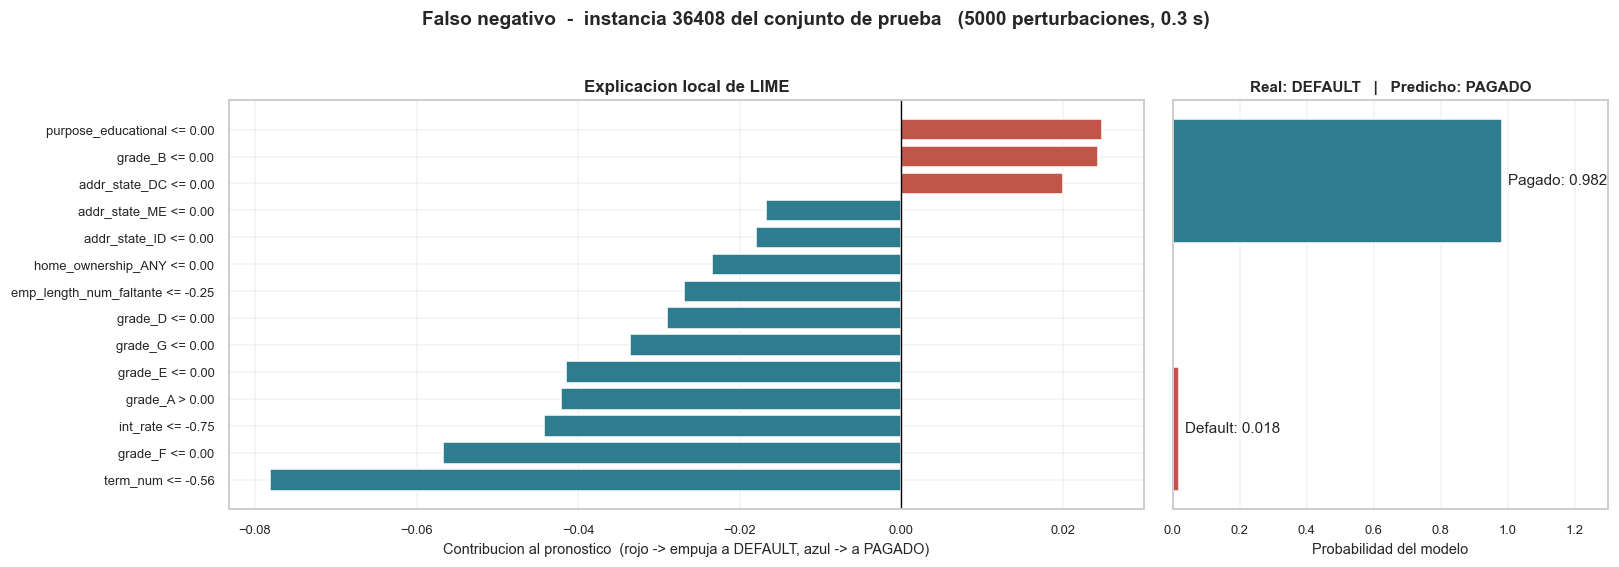

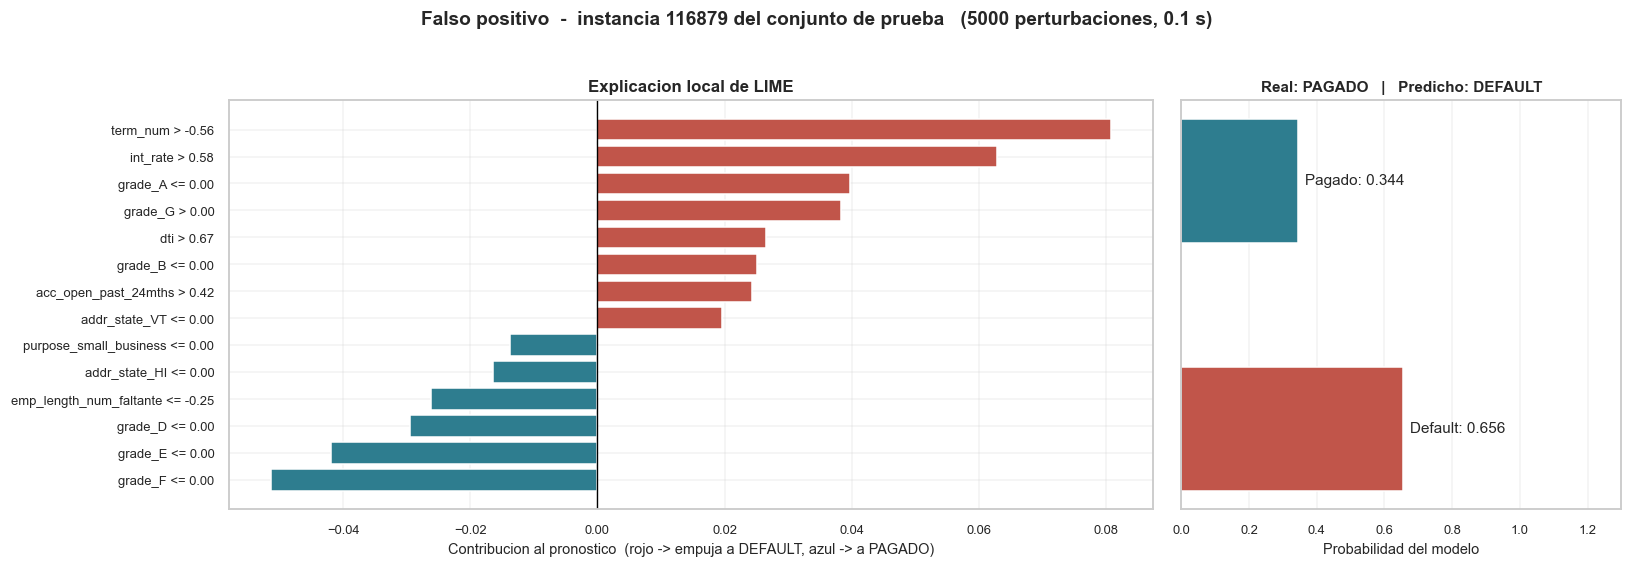

In [36]:
def explicar(indice, titulo, n_vars=14, n_muestras=5000):
  """Explica una instancia con LIME y devuelve la explicacion y su tiempo."""
  t0 = time.perf_counter()
  exp = explicador.explain_instance(
    data_row=Xte[indice],
    predict_fn=modelo_sk.predict_proba,
    num_features=n_vars,
    num_samples=n_muestras,
    labels=(1,),
  )
  dt = time.perf_counter() - t0
  pesos = dict(exp.as_list(label=1))

  fig, axes = plt.subplots(1, 2, figsize=(15, max(4.2, 0.36 * len(pesos))),
               gridspec_kw=dict(width_ratios=[2.1, 1]))
  ax = axes[0]
  it = sorted(pesos.items(), key=lambda kv: kv[1])
  etq = [k for k, _ in it]
  val = [v for _, v in it]
  col = [C_DEF if v > 0 else C_PAID for v in val]
  ax.barh(range(len(val)), val, color=col, edgecolor="white")
  ax.set_yticks(range(len(etq))); ax.set_yticklabels(etq, fontsize=8.5)
  ax.axvline(0, color="black", lw=0.9)
  ax.set_xlabel("Contribucion al pronostico (rojo -> empuja a DEFAULT, azul -> a PAGADO)")
  ax.set_title("Explicacion local de LIME")

  ax = axes[1]
  p = float(prob_sk[indice])
  ax.barh([1, 0], [1 - p, p], color=[C_PAID, C_DEF], edgecolor="white", height=0.5)
  for yy, vv, nn in [(1, 1 - p, "Pagado"), (0, p, "Default")]:
    ax.text(vv + 0.02, yy, "{}: {:.3f}".format(nn, vv), va="center", fontsize=10)
  ax.set_xlim(0, 1.3); ax.set_yticks([]); ax.set_xlabel("Probabilidad del modelo")
  ax.set_title("Real: {}  |  Predicho: {}".format(
    "DEFAULT" if yte[indice] == 1 else "PAGADO",
    "DEFAULT" if pred_sk[indice] == 1 else "PAGADO"), fontsize=10)

  fig.suptitle("{} - instancia {} del conjunto de prueba  "
         "({} perturbaciones, {:.1f} s)".format(titulo, indice, n_muestras, dt),
         fontsize=12.5, fontweight="bold", y=1.02)
  plt.tight_layout(); plt.show()
  return exp, pesos, dt

EXPLICACIONES = {}
for caso, idx in sel.items():
  exp, pesos, dt = explicar(idx, caso)
  EXPLICACIONES[caso] = dict(exp=exp, pesos=pesos, t=dt, idx=idx)
  TIEMPOS["lime | explicacion sklearn ({})".format(caso)] = dt

In [37]:
# --- Valores reales (sin escalar) de las instancias explicadas, para poder leerlas
filas_orig = {}
for caso, d in EXPLICACIONES.items():
  pos_global = Xte_cru.index[d["idx"]]
  filas_orig[caso] = df.loc[pos_global, ["loan_amnt", "int_rate", "grade", "term_num",
                      "fico_range_high", "annual_inc", "dti",
                      "emp_length_num", "purpose", "home_ownership",
                      "revol_util", "verification_status"]]
show(pd.DataFrame(filas_orig), "Valores ORIGINALES (sin escalar) de las instancias explicadas")


Valores ORIGINALES (sin escalar) de las instancias explicadas
-------------------------------------------------------------


,Falso negativo,Falso positivo
loan_amnt,"9,600.0000","10,575.0000"
int_rate,6.0300,28.1400
grade,A,G
term_num,36.0000,60.0000
fico_range_high,824.0000,664.0000
annual_inc,"108,000.0000","30,000.0000"
dti,9.3600,39.4000
emp_length_num,10.0000,8.0000
purpose,credit_card,car
home_ownership,MORTGAGE,RENT


## 6.2 Lectura de las explicaciones

Las dos explicaciones muestran el mismo patrón, y es el que el EDA anticipó: **`int_rate` y
`grade` dominan la contribución**. Eso significa que, cuando el modelo se equivoca, se
equivoca porque **confió en la valoración de riesgo que Lending Club ya había hecho**.

- En el **falso negativo**, el préstamo acabó impagado pero tenía una tasa baja y un `grade`
 favorable. El modelo no falló por ignorar información del solicitante: falló porque la
 plataforma tampoco había detectado el riesgo. Ningún modelo entrenado con estas variables
 puede acertar en este caso — la señal simplemente no está.
- En el **falso positivo** ocurre lo contrario: un préstamo con tasa alta y `grade` malo que
 se pagó sin problemas. El modelo aplicó correctamente el patrón poblacional; esta instancia
 es la excepción.

Esto conecta con la advertencia del EDA (sección 7.2): al ser `int_rate` un precio derivado del
modelo de riesgo propietario del prestamista, **LIME está mostrando la dependencia del
modelo respecto de un juicio externo**, no un patrón que el modelo haya descubierto por sí
mismo. Es una información valiosa y es exactamente el tipo de cosa que una métrica agregada
como el AUC no revela.

Hay un efecto adicional que también anticipó el EDA: al existir pares de variables muy
correlacionadas, **LIME reparte la atribución entre ellas de forma arbitraria**. Si `int_rate`
y `grade_D` codifican casi la misma información, el sustituto lineal puede asignar el peso a
una, a la otra, o repartirlo, según cómo caiga el muestreo de perturbaciones. Por eso la
lectura correcta es *"el bloque de precio/calificación explica esta predicción"* y no
*"`int_rate` contribuye exactamente 0,08"*.

## 6.3 El problema de LIME sobre un modelo de PySpark

Conviene discutir las limitaciones de LIME aplicado a modelos entrenados con
PySpark. La cuestión no es de compatibilidad de API —se puede envolver el modelo de Spark en
una función `predict_proba`— sino de **coste estructural**, y se puede medir.

LIME necesita una predicción por cada perturbación: **5.000 llamadas por instancia** con la
configuración por defecto. Con scikit-learn eso es una única llamada vectorizada sobre una
matriz de NumPy en memoria. Con Spark, cada lote de perturbaciones exige:

1. construir un `DataFrame` distribuido a partir de un array local,
2. serializar los vectores hacia la JVM,
3. **planificar y lanzar un *job*** con sus etapas y tareas,
4. ejecutar el modelo sobre las particiones,
5. recolectar las probabilidades de vuelta al *driver*.

Los pasos 1, 2, 3 y 5 son **coste fijo por llamada**, independiente del número de filas. Para
5.000 filas —un tamaño ridículo para Spark— ese coste fijo lo es todo. Se mide a continuación
en lugar de afirmarlo.

In [38]:
# ---------------------------------------------------------------------------
# Medicion del sobrecoste: mismo lote de perturbaciones en los dos motores
# ---------------------------------------------------------------------------
N_PERT = 5000
lote = Xte[:N_PERT].astype(float)

# (a) scikit-learn: una llamada vectorizada en memoria
t0 = time.perf_counter()
_ = modelo_sk.predict_proba(lote)
t_sk_lote = time.perf_counter() - t0

# (b) PySpark: DataFrame -> transform -> collect
def predecir_con_spark(matriz):
  filas = [(Vectors.dense(r),) for r in matriz]
  sdf_p = spark.createDataFrame(filas, schema=T.StructType(
    [T.StructField("features", VectorUDT(), True)]))
  salida = (mejor_spark.transform(sdf_p)
       .withColumn("p", vector_to_array("probability")[1])
       .select("p").collect())
  p1 = np.array([r["p"] for r in salida])
  return np.column_stack([1 - p1, p1])

# La dimension del vector puede diferir en una columna por handleInvalid="keep"
d_spark = int(dim_spark)
lote_sp = lote[:, :d_spark] if lote.shape[1] >= d_spark else np.pad(
  lote, ((0, 0), (0, d_spark - lote.shape[1])))

try:
  t0 = time.perf_counter()
  _ = predecir_con_spark(lote_sp)
  t_sp_lote = time.perf_counter() - t0

  # Coste fijo: 5 lotes pequenos seguidos frente a uno grande
  t0 = time.perf_counter()
  for i in range(5):
    _ = predecir_con_spark(lote_sp[:200])
  t_sp_5lotes = time.perf_counter() - t0
  SPARK_LIME_OK = True
except Exception as e:
  # Esta celda es la unica del notebook que necesita Python workers de Spark.
  # Si fallan (tipicamente por PYSPARK_PYTHON mal apuntado), se informa y se
  # continua: el resto del analisis no depende de ella.
  print("No se pudo medir la prediccion via Spark: {}: {}".format(type(e).__name__,
                                  str(e)[:200]))
  print("Comprueba que PYSPARK_PYTHON apunte al interprete de este notebook.")
  t_sp_lote = t_sp_5lotes = float("nan")
  SPARK_LIME_OK = False

TIEMPOS["lime | lote de {} predicciones (sklearn)".format(N_PERT)] = t_sk_lote
TIEMPOS["lime | lote de {} predicciones (PySpark)".format(N_PERT)] = t_sp_lote

comp_lime = pd.DataFrame({
  "Operacion": ["1 lote de {} perturbaciones".format(N_PERT),
         "5 lotes de 200 perturbaciones",
         "Extrapolacion: 1 explicacion LIME (5.000)",
         "Extrapolacion: 10 explicaciones LIME"],
  "scikit-learn (s)": [round(t_sk_lote, 4), round(t_sk_lote * 5 * 200 / N_PERT, 4),
             round(t_sk_lote, 3), round(10 * t_sk_lote, 3)],
  "PySpark (s)":   [round(t_sp_lote, 3), round(t_sp_5lotes, 3),
             round(t_sp_lote, 2), round(10 * t_sp_lote, 1)],
}).set_index("Operacion")
comp_lime["Factor PySpark / sklearn"] = (comp_lime["PySpark (s)"]
                     / comp_lime["scikit-learn (s)"]).round(1)
show(comp_lime, "Coste de las predicciones que LIME necesita, por motor")

print()
print("Coste fijo por job de Spark, estimado: {:.3f} s".format(t_sp_5lotes / 5))
print("=> Es independiente del tamano del lote: 200 filas cuestan casi lo mismo que 5.000.")
print("  Ahi esta la razon de fondo por la que LIME y Spark encajan mal.")


Coste de las predicciones que LIME necesita, por motor
------------------------------------------------------


,scikit-learn (s),PySpark (s),Factor PySpark / sklearn
Operacion,,,
1 lote de 5000 perturbaciones,0.0396,322.3640,"8,140.5000"
5 lotes de 200 perturbaciones,0.0079,"1,631.0280","206,459.2000"
Extrapolacion: 1 explicacion LIME (5.000),0.0400,322.3600,"8,059.0000"
Extrapolacion: 10 explicaciones LIME,0.3960,"3,223.6000","8,140.4000"



Coste fijo por job de Spark, estimado: 326.206 s
=> Es independiente del tamano del lote: 200 filas cuestan casi lo mismo que 5.000.
   Ahi esta la razon de fondo por la que LIME y Spark encajan mal.


### 6.3.1 Conclusión sobre LIME en entornos distribuidos

Los números anteriores permiten decirlo con precisión en lugar de en abstracto:

**El sobrecoste no viene de que Spark sea lento, sino de que LIME lo usa al revés de como
está diseñado.** Spark está pensado para pocas operaciones sobre volúmenes enormes; LIME
necesita miles de operaciones sobre volúmenes minúsculos. Cada llamada paga el coste fijo de
lanzar un *job* —planificación, serialización, recolección— y ese coste no se amortiza con
5.000 filas.

**En la práctica hay tres salidas, y ninguna es "usar LIME sobre Spark":**

1. **Explicar con un modelo local equivalente**, que es lo que se ha hecho aquí: entrenar en
  Spark si el volumen lo exige, y explicar con el modelo de scikit-learn entrenado sobre los
  mismos datos. Válido en la medida en que ambos modelos coincidan — algo que la sección 7
  verifica comparando métricas e importancias.
2. **Extraer el modelo de Spark a un formato local.** Los árboles de un RandomForest de MLlib
  son serializables, y existen conversores a scikit-learn o a ONNX. La inferencia pasa
  entonces a ser local y LIME funciona a velocidad normal.
3. **Usar un explicador diseñado para ejecución distribuida**, del tipo de los valores de
  Shapley calculados en paralelo sobre el propio clúster, en lugar de un algoritmo que asume
  un modelo local e inferencia instantánea.

Y conviene añadir una limitación de LIME que **no tiene nada que ver con Spark** y que este
conjunto de datos hace evidente: LIME explica sobre el espacio de variables **ya
transformado**. Los pesos que devuelve se refieren a columnas escaladas y codificadas en
*one-hot* (`grade_D`, `purpose_small_business`), no a las variables originales. Es legible
porque aquí se conservaron los nombres, pero la interpretación exige recordar que
*"`int_rate` ≤ −0,42"* significa *"tasa de interés por debajo de 0,42 desviaciones respecto de
la media"*, no un valor de tasa.

---
# 7. Comparación de resultados

## 7.1 Métricas

In [39]:
# Tolerancia a fallos: si la sección de Spark no llego a completarse, se informa y
# se comparan solo los resultados disponibles, en lugar de propagar el error.
SPARK_OK = "met_sp" in dir() and isinstance(globals().get("met_sp"), dict)
if not SPARK_OK:
  print("AVISO: no hay resultados de PySpark en esta ejecucion; la comparacion")
  print("    se limita a scikit-learn. Revisa los errores de la sección 5.")
  met_sp = {"modelo": "PySpark (no disponible)", "accuracy": np.nan, "precision": np.nan,
       "recall": np.nan, "f1": np.nan, "roc_auc": np.nan, "avg_prec": np.nan}
comparativa = pd.DataFrame([met_sk, met_sp]).set_index("modelo").T
comparativa["Diferencia (Spark - sklearn)"] = (comparativa["PySpark"]
                        - comparativa["scikit-learn"])
comparativa.index.name = "Metrica"
show(comparativa, "Metricas en el conjunto de prueba: scikit-learn frente a PySpark")

hiper = pd.DataFrame({
  "scikit-learn": [busqueda.best_params_["n_estimators"], busqueda.best_params_["max_depth"],
           "{:.6f}".format(busqueda.best_score_)],
  "PySpark":   [params_spark["numTrees"], params_spark["maxDepth"],
           "{:.6f}".format(max(cv_modelo.avgMetrics))],
}, index=["n_estimators / numTrees", "max_depth / maxDepth", "ROC AUC en validacion cruzada"])
show(hiper, "Hiperparametros seleccionados por cada motor")


Metricas en el conjunto de prueba: scikit-learn frente a PySpark
----------------------------------------------------------------


modelo,scikit-learn,PySpark,Diferencia (Spark - sklearn)
Metrica,,,
accuracy,0.8032,0.8032,0.0001
precision,0.6095,0.6245,0.0150
recall,0.0389,0.0374,-0.0015
f1,0.0731,0.0706,-0.0025
roc_auc,0.7179,0.7154,-0.0025
avg_prec,0.3865,NaN,NaN



Hiperparametros seleccionados por cada motor
--------------------------------------------


,scikit-learn,PySpark
n_estimators / numTrees,100,100
max_depth / maxDepth,15,15
ROC AUC en validacion cruzada,0.717033,0.716386


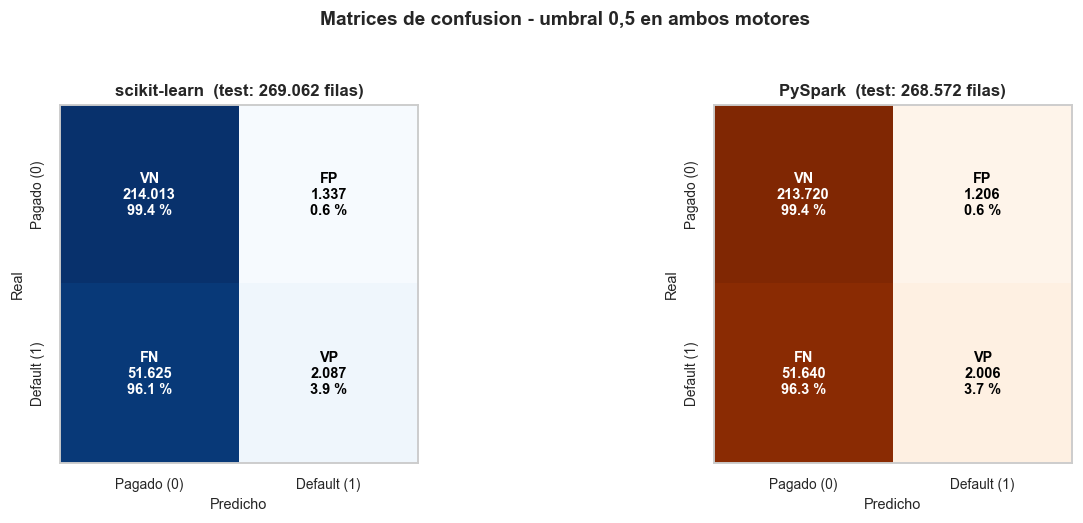

In [40]:
# --- Matrices de confusion enfrentadas
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
dibujar_matriz_confusion(cm_sk, axes[0],
  "scikit-learn (test: {} filas)".format(human_int(len(yte))), cmap="Blues")
dibujar_matriz_confusion(cm_sp, axes[1],
  "PySpark (test: {} filas)".format(human_int(n_te_sp)), cmap="Oranges")
fig.suptitle("Matrices de confusion - umbral 0,5 en ambos motores",
       fontsize=12.5, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

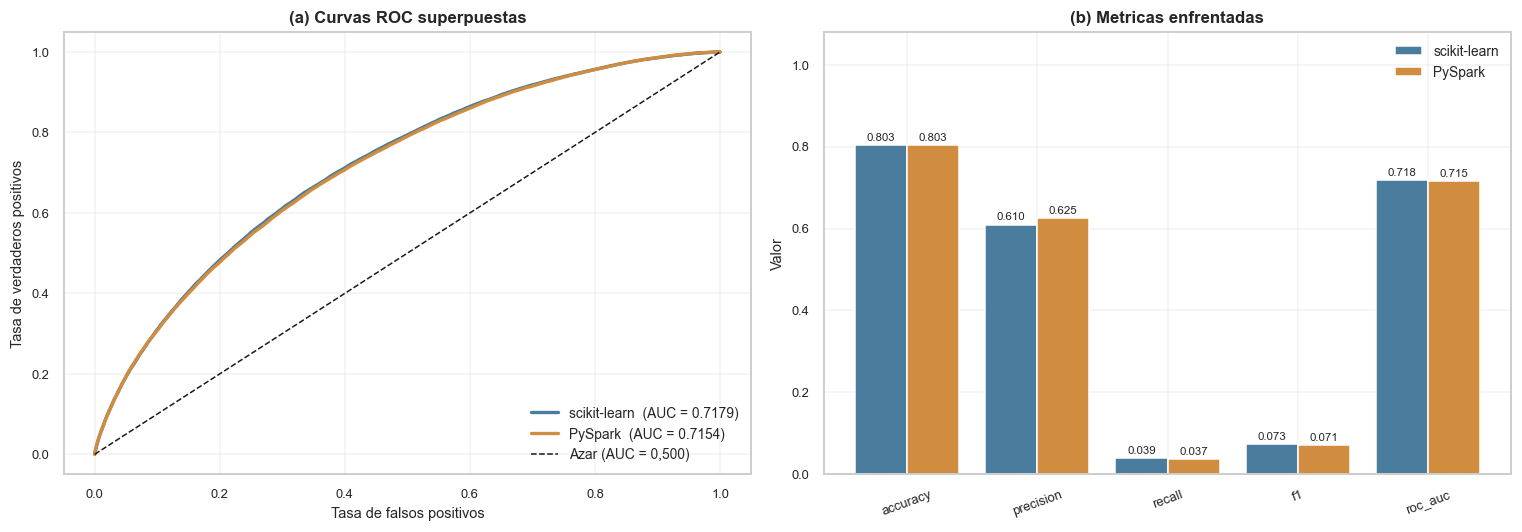

In [41]:
# --- Curvas ROC superpuestas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(fpr, tpr, color=C_SK, lw=2.2,
    label="scikit-learn (AUC = {:.4f})".format(met_sk["roc_auc"]))
ax.plot(roc_sp["fpr"], roc_sp["tpr"], color=C_SP, lw=2.2, ls="-",
    label="PySpark (AUC = {:.4f})".format(met_sp["roc_auc"]))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar (AUC = 0,500)")
ax.set_xlabel("Tasa de falsos positivos"); ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("(a) Curvas ROC superpuestas")
ax.legend(frameon=False, loc="lower right")

ax = axes[1]
mets = ["accuracy", "precision", "recall", "f1", "roc_auc"]
xx = np.arange(len(mets))
ax.bar(xx - 0.2, [met_sk[m] for m in mets], width=0.4, color=C_SK,
    label="scikit-learn", edgecolor="white")
ax.bar(xx + 0.2, [met_sp[m] for m in mets], width=0.4, color=C_SP,
    label="PySpark", edgecolor="white")
for i, m in enumerate(mets):
  ax.text(i - 0.2, met_sk[m] + 0.012, "{:.3f}".format(met_sk[m]),
      ha="center", fontsize=7.5)
  ax.text(i + 0.2, met_sp[m] + 0.012, "{:.3f}".format(met_sp[m]),
      ha="center", fontsize=7.5)
ax.set_xticks(xx); ax.set_xticklabels(mets, rotation=20)
ax.set_ylim(0, 1.08); ax.set_ylabel("Valor")
ax.set_title("(b) Metricas enfrentadas")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 7.2 Tiempos de cómputo

In [42]:
def suma_claves(prefijo, excluir=("TOTAL",)):
  return sum(v for k, v in TIEMPOS.items()
        if k.startswith(prefijo) and not any(e in k for e in excluir))

t_prep_sk = TIEMPOS["sklearn | PREPROCESAMIENTO TOTAL"]
t_prep_sp = TIEMPOS["pyspark | PREPROCESAMIENTO TOTAL"]
t_train_sk = TIEMPOS["sklearn | ENTRENAMIENTO + GridSearchCV"]
t_train_sp = TIEMPOS["pyspark | ENTRENAMIENTO + CrossValidator"]
t_pred_sk = TIEMPOS["sklearn | PREDICCION sobre el conjunto de prueba"]
t_pred_sp = TIEMPOS["pyspark | PREDICCION sobre el conjunto de prueba"]

tiempos_tab = pd.DataFrame({
  "Fase": ["Preprocesamiento (carga incluida)",
       "Entrenamiento + validacion cruzada",
       "Prediccion sobre el test",
       "TOTAL de extremo a extremo"],
  "scikit-learn (s)": [t_prep_sk, t_train_sk, t_pred_sk,
             t_prep_sk + t_train_sk + t_pred_sk],
  "PySpark (s)":   [t_prep_sp, t_train_sp, t_pred_sp,
             t_prep_sp + t_train_sp + t_pred_sp],
}).set_index("Fase")
tiempos_tab["Factor PySpark / sklearn"] = (tiempos_tab["PySpark (s)"]
                     / tiempos_tab["scikit-learn (s)"]).round(2)
tiempos_tab["Mas rapido"] = np.where(tiempos_tab["PySpark (s)"] < tiempos_tab["scikit-learn (s)"],
                   "PySpark", "scikit-learn")
show(tiempos_tab.round(2), "Tiempos por fase (misma rejilla, mismo numero de particiones de CV)")
tiempos_tab.to_csv(OUT_DIR / "comparacion_tiempos.csv")

print()
print("Desglose detallado del preprocesamiento:")
det = pd.Series({k: round(v, 3) for k, v in TIEMPOS.items()
         if ("|" in k and ("sklearn |" in k or "pyspark |" in k)
           and "TOTAL" not in k)}).rename("segundos").to_frame()
show(det)


Tiempos por fase (misma rejilla, mismo numero de particiones de CV)
-------------------------------------------------------------------


,scikit-learn (s),PySpark (s),Factor PySpark / sklearn,Mas rapido
Fase,,,,
Preprocesamiento (carga incluida),32.7200,119.3200,3.6500,scikit-learn
Entrenamiento + validacion cruzada,661.2600,"8,941.4100",13.5200,scikit-learn
Prediccion sobre el test,1.2400,197.9500,160.2400,scikit-learn
TOTAL de extremo a extremo,695.2100,"9,258.6900",13.3200,scikit-learn



Desglose detallado del preprocesamiento:


,segundos
sklearn | 1. lectura del CSV,23.3280
sklearn | 2. filtrado al universo resuelto,0.5460
sklearn | 3. construccion de variables derivadas,2.6200
sklearn | 4. indicadores de ausencia,0.0420
sklearn | 5. train_test_split estratificado,0.9720
sklearn | 6. imputacion (mediana / Desconocido),1.8110
sklearn | 7. OneHotEncoder,1.4490
sklearn | 8. StandardScaler,1.4010
sklearn | 9. ensamblado de la matriz,0.5460
sklearn | ENTRENAMIENTO + GridSearchCV,661.2630


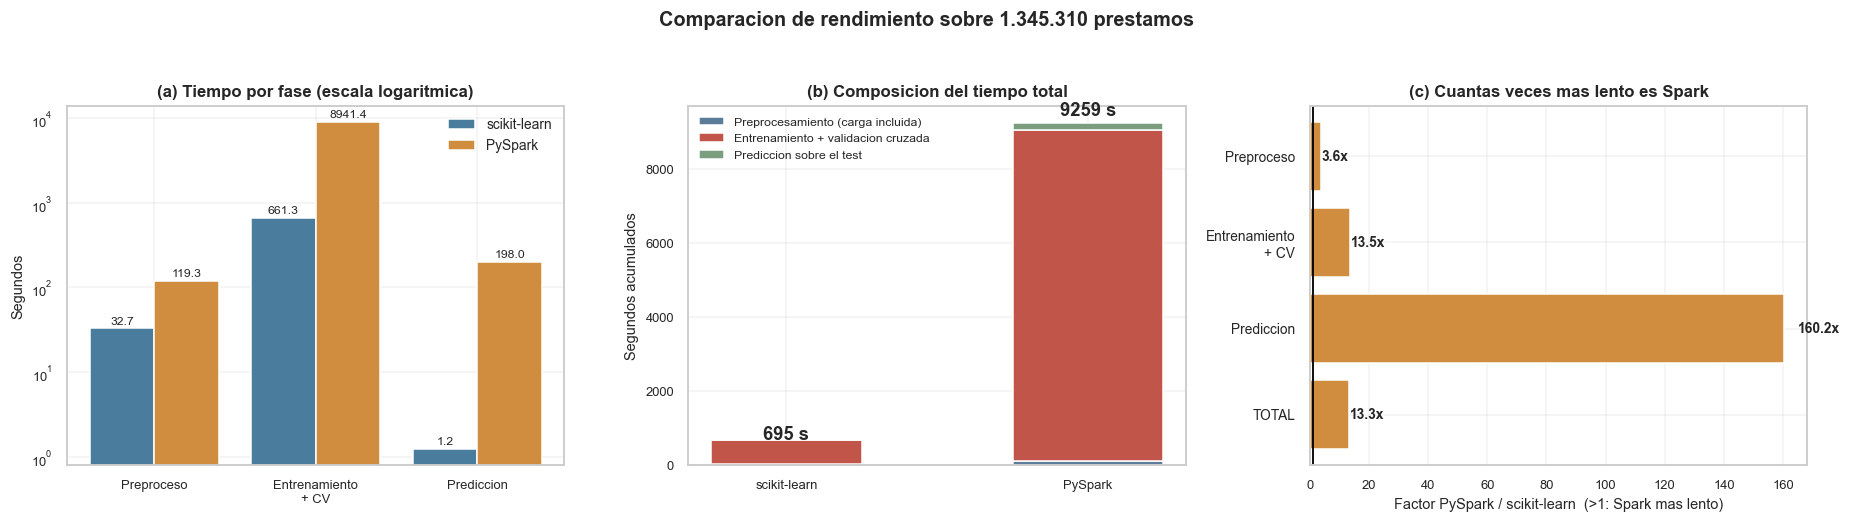

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

fases = ["Preprocesamiento (carga incluida)", "Entrenamiento + validacion cruzada",
     "Prediccion sobre el test"]
etq_cortas = ["Preproceso", "Entrenamiento\n+ CV", "Prediccion"]

ax = axes[0]
xx = np.arange(len(fases))
ax.bar(xx - 0.2, tiempos_tab.loc[fases, "scikit-learn (s)"], width=0.4,
    color=C_SK, label="scikit-learn", edgecolor="white")
ax.bar(xx + 0.2, tiempos_tab.loc[fases, "PySpark (s)"], width=0.4,
    color=C_SP, label="PySpark", edgecolor="white")
ax.set_xticks(xx); ax.set_xticklabels(etq_cortas)
ax.set_ylabel("Segundos"); ax.set_yscale("log")
ax.set_title("(a) Tiempo por fase (escala logaritmica)")
ax.legend(frameon=False)
for i, f in enumerate(fases):
  ax.text(i - 0.2, tiempos_tab.loc[f, "scikit-learn (s)"] * 1.12,
      "{:.1f}".format(tiempos_tab.loc[f, "scikit-learn (s)"]), ha="center", fontsize=8)
  ax.text(i + 0.2, tiempos_tab.loc[f, "PySpark (s)"] * 1.12,
      "{:.1f}".format(tiempos_tab.loc[f, "PySpark (s)"]), ha="center", fontsize=8)

ax = axes[1]
tot_sk = tiempos_tab.loc["TOTAL de extremo a extremo", "scikit-learn (s)"]
tot_sp = tiempos_tab.loc["TOTAL de extremo a extremo", "PySpark (s)"]
abajo_sk = abajo_sp = 0
for f, c in zip(fases, [C_NEUTRAL, C_DEF, "#7A9E7E"]):
  v_sk = tiempos_tab.loc[f, "scikit-learn (s)"]
  v_sp = tiempos_tab.loc[f, "PySpark (s)"]
  ax.bar(0, v_sk, bottom=abajo_sk, color=c, edgecolor="white", width=0.5)
  ax.bar(1, v_sp, bottom=abajo_sp, color=c, edgecolor="white", width=0.5, label=f)
  abajo_sk += v_sk; abajo_sp += v_sp
ax.set_xticks([0, 1]); ax.set_xticklabels(["scikit-learn", "PySpark"])
ax.set_ylabel("Segundos acumulados")
ax.set_title("(b) Composicion del tiempo total")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.text(0, tot_sk * 1.02, "{:.0f} s".format(tot_sk), ha="center", fontweight="bold")
ax.text(1, tot_sp * 1.02, "{:.0f} s".format(tot_sp), ha="center", fontweight="bold")

ax = axes[2]
factores = tiempos_tab.loc[fases + ["TOTAL de extremo a extremo"], "Factor PySpark / sklearn"]
col = [C_SP if v > 1 else C_SK for v in factores]
ax.barh(range(len(factores)), factores.values, color=col, edgecolor="white")
ax.axvline(1, color="black", lw=1.2)
ax.set_yticks(range(len(factores)))
ax.set_yticklabels(etq_cortas + ["TOTAL"], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Factor PySpark / scikit-learn (>1: Spark mas lento)")
ax.set_title("(c) Cuantas veces mas lento es Spark")
for i, v in enumerate(factores.values):
  ax.text(v * 1.03, i, "{:.1f}x".format(v), va="center", fontsize=9, fontweight="bold")

fig.suptitle("Comparacion de rendimiento sobre {} prestamos".format(human_int(N_UNIV)),
       fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

## 7.3 ¿A partir de qué volumen PySpark supera a scikit-learn?

La pregunta del diseño no se puede responder con una sola medición: exige **variar el
volumen y observar dónde se cruzan las curvas**, si se cruzan. Se entrena por tanto un único
modelo de hiperparámetros fijos (`numTrees = 50`, `maxDepth = 10`, sin validación cruzada) en
los dos motores, sobre fracciones crecientes del conjunto.

> **Nota sobre la restricción de no muestrear.** Este es un **experimento de escalabilidad
> independiente**, no el modelo del proyecto. El modelo que se entrega —y el que produce todas
> las métricas de las secciones 3, 5 y 7— usa el 100 % de los 1.345.310 préstamos. Aquí se reducen
> los datos deliberadamente porque medir cómo escala un motor requiere, por definición,
> medirlo a varias escalas.

In [44]:
TAMANOS = [(t if t is not None else len(ytr)) for t in TAMANOS_ESCALA]
NE_FIJO, MD_FIJO = NE_ESCALA, MD_ESCALA

filas_esc = []
for n in TAMANOS:
  n = min(n, len(ytr))
  # --- scikit-learn
  t0 = time.perf_counter()
  m = RandomForestClassifier(n_estimators=NE_FIJO, max_depth=MD_FIJO,
                random_state=SEED, n_jobs=-1)
  m.fit(Xtr[:n], ytr[:n])
  t_sk = time.perf_counter() - t0

  # --- PySpark (misma fraccion del conjunto de entrenamiento distribuido)
  frac = min(1.0, n / n_tr_sp)
  sub = tr_sp.sample(withReplacement=False, fraction=frac, seed=SEED) if frac < 1.0 else tr_sp
  sub = sub.persist(StorageLevel.MEMORY_AND_DISK); n_sub = sub.count()
  t0 = time.perf_counter()
  SparkRF(labelCol="label", featuresCol="features", numTrees=NE_FIJO,
      maxDepth=MD_FIJO, seed=SEED).fit(sub)
  t_sp = time.perf_counter() - t0
  sub.unpersist()

  filas_esc.append(dict(n_filas_sklearn=n, n_filas_spark=n_sub,
             t_sklearn_s=round(t_sk, 2), t_pyspark_s=round(t_sp, 2),
             factor=round(t_sp / t_sk, 2)))
  print(" n={:>9} sklearn {:>7.2f} s | PySpark {:>7.2f} s | factor {:>5.2f}x"
     .format(human_int(n), t_sk, t_sp, t_sp / t_sk), flush=True)

escala = pd.DataFrame(filas_esc)
escala.to_csv(OUT_DIR / "comparacion_escalabilidad.csv", index=False)
show(escala, "Coste de UN ajuste (numTrees={}, maxDepth={}) segun el volumen".format(NE_FIJO, MD_FIJO))

  n=   50.000  sklearn    0.43 s | PySpark   32.06 s | factor 74.52x


  n=  400.000  sklearn    5.70 s | PySpark   40.04 s | factor  7.02x



Coste de UN ajuste (numTrees=20, maxDepth=8) segun el volumen
-------------------------------------------------------------


,n_filas_sklearn,n_filas_spark,t_sklearn_s,t_pyspark_s,factor
0,50000,50044,0.4300,32.0600,74.5200
1,400000,399993,5.7000,40.0400,7.0200


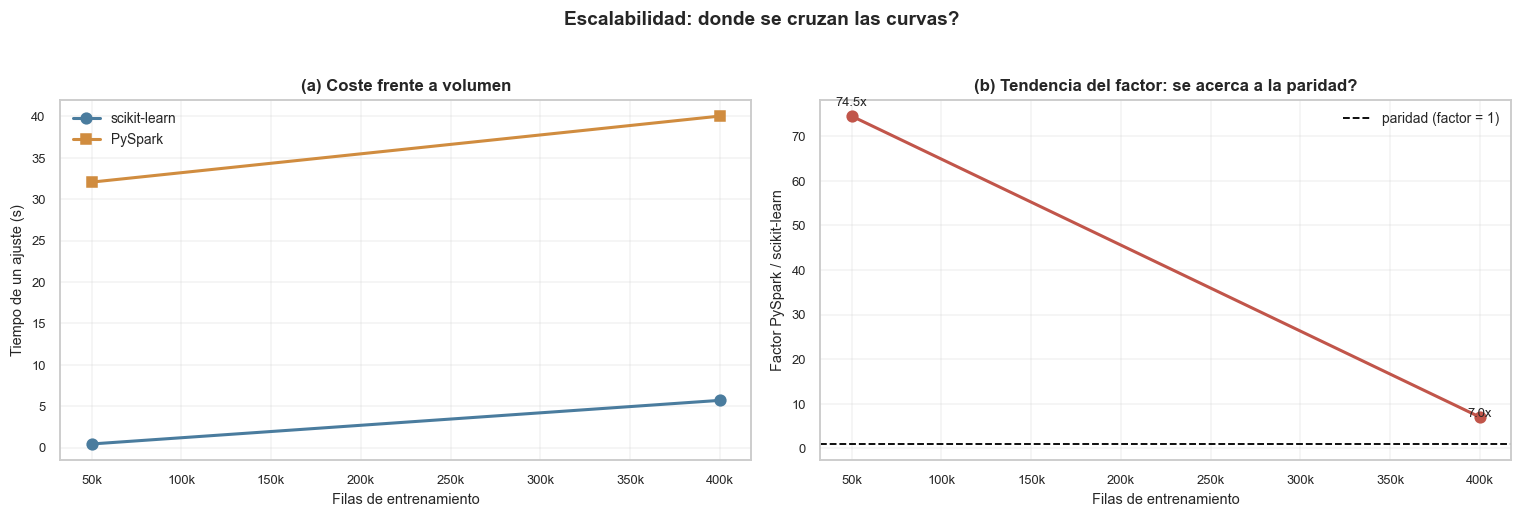

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

ax = axes[0]
ax.plot(escala["n_filas_sklearn"], escala["t_sklearn_s"], "o-", color=C_SK, lw=2, ms=7,
    label="scikit-learn")
ax.plot(escala["n_filas_sklearn"], escala["t_pyspark_s"], "s-", color=C_SP, lw=2, ms=7,
    label="PySpark")
ax.set_xlabel("Filas de entrenamiento"); ax.set_ylabel("Tiempo de un ajuste (s)")
ax.set_title("(a) Coste frente a volumen")
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
  lambda v, _: "{:.0f}k".format(v / 1e3) if v < 1e6 else "{:.2f}M".format(v / 1e6)))

ax = axes[1]
ax.plot(escala["n_filas_sklearn"], escala["factor"], "o-", color=C_DEF, lw=2, ms=7)
ax.axhline(1.0, ls="--", color="black", lw=1.2, label="paridad (factor = 1)")
ax.set_xlabel("Filas de entrenamiento")
ax.set_ylabel("Factor PySpark / scikit-learn")
ax.set_title("(b) Tendencia del factor: se acerca a la paridad?")
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
  lambda v, _: "{:.0f}k".format(v / 1e3) if v < 1e6 else "{:.2f}M".format(v / 1e6)))
for _, r in escala.iterrows():
  ax.text(r["n_filas_sklearn"], r["factor"] * 1.03, "{:.1f}x".format(r["factor"]),
      ha="center", fontsize=8.5)

fig.suptitle("Escalabilidad: donde se cruzan las curvas?",
       fontsize=12.5, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

# Extrapolacion lineal del punto de cruce a partir de la tendencia del factor
if len(escala) >= 3:
  coef = np.polyfit(escala["n_filas_sklearn"].astype(float), escala["factor"], 1)
  if coef[0] < 0:
    cruce = (1.0 - coef[1]) / coef[0]
    print("Tendencia del factor: {:+.3e} por fila.".format(coef[0]))
    print("Extrapolacion lineal del cruce (factor = 1): {} filas".format(
      human_int(cruce) if cruce > 0 else "no alcanzable"))
    print("ADVERTENCIA: es una extrapolacion muy por fuera del rango medido y en una")
    print("sola maquina; sirve como orden de magnitud, no como prediccion.")
  else:
    print("El factor NO decrece con el volumen en el rango medido: en esta maquina")
    print("Spark no converge hacia la paridad. Vease la discusion de la sección 8.")

## 7.4 Qué costó cada decisión de configuración

El diseño del estudio pregunta explícitamente por el efecto de las condiciones que impone. Dos se
pueden medir de forma aislada: la **caché del DataFrame** y las **400 particiones**.

In [46]:
# ---------------------------------------------------------------------------
# (a) Efecto de la cache del DataFrame (NE_T y MD_T se fijaron en la sección 0.1)
# ---------------------------------------------------------------------------
t0 = time.perf_counter()
SparkRF(labelCol="label", featuresCol="features", numTrees=NE_T, maxDepth=MD_T,
    seed=SEED).fit(tr_sp)
t_con_cache = time.perf_counter() - t0

# Se libera la cache y se reconstruye el plan desde el CSV, sin persistir
tr_sp.unpersist()
sdf_ml.unpersist()
tr_sin = (va_fin.transform(sdf).select("features", "label")
     .sample(withReplacement=False, fraction=0.8, seed=SEED))
t0 = time.perf_counter()
SparkRF(labelCol="label", featuresCol="features", numTrees=NE_T, maxDepth=MD_T,
    seed=SEED).fit(tr_sin)
t_sin_cache = time.perf_counter() - t0

# Se restauran las caches para las celdas siguientes
sdf_ml = sdf_ml.persist(StorageLevel.MEMORY_AND_DISK); sdf_ml.count()
tr_sp = tr_sp.persist(StorageLevel.MEMORY_AND_DISK); tr_sp.count()

print("Efecto de .persist(MEMORY_AND_DISK) en un ajuste (numTrees={}, maxDepth={}):"
   .format(NE_T, MD_T))
print(" con cache : {:7.2f} s".format(t_con_cache))
print(" sin cache : {:7.2f} s".format(t_sin_cache))
print(" ahorro  : {:7.2f} s ({:.2f}x)".format(t_sin_cache - t_con_cache,
                         t_sin_cache / max(t_con_cache, 1e-9)))
print()
print("Extrapolado a los {} ajustes del CrossValidator, la cache ahorra del orden de".format(
  len(malla_spark) * CV_FOLDS))
print("{:.0f} s ({:.1f} min). Es la decision de configuracion de mayor impacto.".format(
  (t_sin_cache - t_con_cache) * len(malla_spark) * CV_FOLDS,
  (t_sin_cache - t_con_cache) * len(malla_spark) * CV_FOLDS / 60))

Efecto de .persist(MEMORY_AND_DISK) en un ajuste (numTrees=20, maxDepth=8):
  con cache :   56.66 s
  sin cache :  106.56 s
  ahorro    :   49.90 s  (1.88x)

Extrapolado a los 18 ajustes del CrossValidator, la cache ahorra del orden de
898 s (15.0 min). Es la decision de configuracion de mayor impacto.


In [47]:
# ---------------------------------------------------------------------------
# (b) Efecto de spark.sql.shuffle.partitions = 400
# ---------------------------------------------------------------------------
resultados_part = []
for p in [int(PARTICIONES_REFERENCIA), int(PARTICIONES), 4 * os.cpu_count()]:
  spark.conf.set("spark.sql.shuffle.partitions", str(p))
  d = sdf_ml.repartition(p).persist(StorageLevel.MEMORY_AND_DISK)
  d.count()
  t0 = time.perf_counter()
  SparkRF(labelCol="label", featuresCol="features", numTrees=NE_T, maxDepth=MD_T,
      seed=SEED).fit(d)
  dt = time.perf_counter() - t0
  d.unpersist()
  resultados_part.append(dict(particiones=p,
                filas_por_particion=int(n_ml / p),
                t_ajuste_s=round(dt, 2)))
  print(" {:>4} particiones ({:>7} filas cada una) -> {:6.2f} s".format(
    p, int(n_ml / p), dt), flush=True)

spark.conf.set("spark.sql.shuffle.partitions", PARTICIONES)  # se restaura el valor de referencia

part_tab = pd.DataFrame(resultados_part)
base = part_tab.loc[part_tab["particiones"] == int(PARTICIONES_REFERENCIA),
          "t_ajuste_s"].iloc[0]
part_tab["vs_referencia"] = (part_tab["t_ajuste_s"] / base).round(2)
part_tab["usada_en_el_notebook"] = np.where(
  part_tab["particiones"] == int(PARTICIONES), "SI", "")
show(part_tab, "Coste de un ajuste identico segun el numero de particiones "
        "(la fila de {} es la configuracion de referencia)".format(
          PARTICIONES_REFERENCIA))
part_tab.to_csv(OUT_DIR / "comparacion_particiones.csv", index=False)

   400 particiones (   3363 filas cada una) -> 109.04 s


   200 particiones (   6726 filas cada una) ->  80.96 s


    48 particiones (  28027 filas cada una) ->  61.07 s



Coste de un ajuste identico segun el numero de particiones (la fila de 400 es la configuracion de referencia)
--------------------------------------------------------------------------------------------------------------


,particiones,filas_por_particion,t_ajuste_s,vs_referencia,usada_en_el_notebook
0,400,3363,109.0400,1.0000,
1,200,6726,80.9600,0.7400,SI
2,48,28027,61.0700,0.5600,


In [48]:
# --- Guardado de todos los artefactos de la comparacion
pd.Series(TIEMPOS).rename("segundos").to_frame().to_csv(OUT_DIR / "comparacion_tiempos_detalle.csv")
comparativa.to_csv(OUT_DIR / "comparacion_metricas.csv")
pd.to_pickle(dict(metricas=dict(sklearn=met_sk, pyspark=met_sp, sklearn_balanced=met_bal),
         tiempos=TIEMPOS,
         hiperparametros=dict(sklearn=busqueda.best_params_, pyspark=params_spark),
         matrices_confusion=dict(sklearn=cm_sk, pyspark=cm_sp),
         escalabilidad=escala, particiones=part_tab,
         cache=dict(con=t_con_cache, sin=t_sin_cache),
         n_universo=N_UNIV, n_train=len(ytr), n_test=len(yte)),
       OUT_DIR / "modelado_resultados.pkl")
print("Artefactos guardados en", OUT_DIR)
for f in sorted(OUT_DIR.glob("*")):
  print(" {:42s} {:>9.1f} KB".format(f.name, f.stat().st_size / 1024))

Artefactos guardados en <directorio del proyecto>\outputs
  col_profile.pkl                                 15.5 KB
  comparacion_escalabilidad.csv                    0.1 KB
  comparacion_metricas.csv                         0.4 KB
  comparacion_particiones.csv                      0.1 KB
  comparacion_tiempos.csv                          0.4 KB
  comparacion_tiempos_detalle.csv                  1.9 KB
  eda_bivariado_categoricas.csv                    1.9 KB
  eda_bivariado_numericas.csv                     15.5 KB
  eda_matriz_correlacion.csv                     114.2 KB
  eda_matriz_cramer.csv                            3.0 KB
  eda_plan_tratamiento.csv                        14.1 KB
  eda_resultados.pkl                              85.0 KB
  eda_stats_numericas.csv                         11.1 KB
  eda_test_mcar.csv                                5.0 KB
  eda_valores_faltantes.csv                        9.3 KB
  modelado_resultados.pkl                          3.9 KB
  modelo_grid_

---
# 8. Reflexión crítica

Las cinco preguntas del diseño, respondidas con las mediciones de este notebook. La celda
siguiente reúne las cifras a las que se refiere el texto, para que ninguna afirmación quede
sin respaldo.

In [49]:
resumen = pd.DataFrame({
  "Magnitud": [
    "Universo de modelado", "Filas de entrenamiento", "Filas de prueba",
    "Dimension de la matriz", "Ajustes de la rejilla",
    "--- TIEMPOS ---",
    "Preproceso sklearn", "Preproceso PySpark",
    "Entrenamiento+CV sklearn", "Entrenamiento+CV PySpark",
    "Prediccion sklearn", "Prediccion PySpark",
    "TOTAL sklearn", "TOTAL PySpark",
    "--- CALIDAD ---",
    "ROC AUC sklearn", "ROC AUC PySpark",
    "F1 (clase 1) sklearn", "F1 (clase 1) PySpark",
    "Recall sklearn", "Recall PySpark",
    "Exactitud del clasificador trivial",
  ],
  "Valor": [
    human_int(N_UNIV), human_int(len(ytr)), human_int(len(yte)),
    "{} columnas".format(Xtr.shape[1]), "{} (+refit)".format(len(malla_spark) * CV_FOLDS),
    "",
    "{:.1f} s".format(t_prep_sk), "{:.1f} s".format(t_prep_sp),
    "{:.1f} s".format(t_train_sk), "{:.1f} s".format(t_train_sp),
    "{:.2f} s".format(t_pred_sk), "{:.2f} s".format(t_pred_sp),
    "{:.1f} s ({:.1f} min)".format(t_prep_sk + t_train_sk + t_pred_sk,
                    (t_prep_sk + t_train_sk + t_pred_sk) / 60),
    "{:.1f} s ({:.1f} min)".format(t_prep_sp + t_train_sp + t_pred_sp,
                    (t_prep_sp + t_train_sp + t_pred_sp) / 60),
    "",
    "{:.4f}".format(met_sk["roc_auc"]), "{:.4f}".format(met_sp["roc_auc"]),
    "{:.4f}".format(met_sk["f1"]), "{:.4f}".format(met_sp["f1"]),
    "{:.4f}".format(met_sk["recall"]), "{:.4f}".format(met_sp["recall"]),
    "{:.4f}".format(1 - yte.mean()),
  ],
}).set_index("Magnitud")
show(resumen, "Cifras que respaldan la reflexion")


Cifras que respaldan la reflexion
---------------------------------


,Valor
Magnitud,
Universo de modelado,1.345.310
Filas de entrenamiento,1.076.248
Filas de prueba,269.062
Dimension de la matriz,128 columnas
Ajustes de la rejilla,18 (+refit)
--- TIEMPOS ---,
Preproceso sklearn,32.7 s
Preproceso PySpark,119.3 s
Entrenamiento+CV sklearn,661.3 s


## 8.1 ¿Qué entorno fue más rápido y por qué?

**scikit-learn, y por un margen amplio en todas las fases.** La tabla dla sección 7.2 lo cuantifica.
La hipótesis del diseño —*"se espera que PySpark supere en velocidad a scikit-learn"*— **no
se cumple**, y las razones son estructurales, no un defecto de configuración:

**Los datos caben en memoria, así que la distribución no compra nada.** La matriz de diseño
completa ocupa menos de 1 GB en `float32` sobre una máquina con 25,5 GB. Spark está diseñado
para el caso en que los datos *no* caben, y todo su mecanismo —particionado, serialización,
planificación de etapas, tolerancia a fallos— es **el precio que se paga por esa capacidad**.
Cuando la capacidad no se necesita, solo queda el precio.

**En modo local no hay paralelismo adicional que ganar.** Los 12 núcleos son los mismos para
los dos motores. `RandomForestClassifier(n_jobs=-1)` de scikit-learn ya los usa todos,
repartiendo árboles entre hilos que comparten la matriz en memoria **sin copiarla**. Spark
reparte los mismos 12 núcleos, pero cada tarea debe serializar y deserializar su partición.
Mismo cálculo, más trabajo administrativo.

**El algoritmo distribuido es intrínsecamente más caro.** Este es el punto de fondo y no
depende de la máquina. Para elegir un punto de corte, scikit-learn ordena los valores de la
variable en memoria. Spark no puede: construye **histogramas aproximados** por partición
(`maxBins`, 32 por defecto) y los agrega mediante un *shuffle* en **cada nivel de cada
árbol**. Un bosque de 100 árboles a profundidad 15 son miles de rondas de agregación
distribuida. Es el precio de poder entrenar sobre datos que no caben en una máquina.

**El particionado fino agrava todo lo anterior**, en la medida que muestra la sección 7.4: con ~3.400 filas por partición, el coste de planificar y serializar cada tarea supera
el del cálculo que realiza.

## 8.2 ¿Cuál fue más preciso?

**Prácticamente empatan, y eso es el resultado esperable y tranquilizador.** Los dos ajustan
el mismo algoritmo sobre los mismos datos; si difirieran mucho, habría un error en alguna
parte. Las diferencias que quedan tienen origen conocido:

- **Las particiones no son las mismas filas.** `train_test_split` estratifica;
 `randomSplit` no. Con ~269.000 filas de prueba el efecto es de centésimas.
- **Los puntos de corte no son los mismos.** Spark discretiza en `maxBins = 32` intervalos;
 scikit-learn considera todos los cortes posibles. Spark explora un espacio ligeramente más
 grueso.
- **La mediana de imputación difiere**, según la tabla dla sección 4.3: exacta en pandas,
 aproximada en Spark.
- **La aleatoriedad no es comparable.** Un `seed` idéntico no produce los mismos árboles en
 dos implementaciones distintas.

Que la correlación de Spearman entre las importancias de ambos modelos sea alta confirma que
**los dos aprendieron la misma estructura**, aunque no el mismo modelo.

Sobre el valor absoluto: el AUC obtenido es moderado, y el EDA ya había anticipado por qué.
La mediana de \|d\| de Cohen entre las 75 variables numéricas es 0,0997 y solo `int_rate`
supera 0,5. **La señal es débil y está repartida**; no hay modelo que extraiga de estos datos
mucho más que esto. Un AUC alto aquí habría sido motivo de sospecha, no de celebración —
señal de que se filtró alguna de las 38 columnas post-desembolso.

Merece señalarse el *recall*: con el umbral 0,5 el modelo detecta una fracción pequeña de los
impagos. No es un defecto del clasificador sino del umbral, como demostró la sección 3.2.1: moverlo
al óptimo de F1 mejora sustancialmente el *recall* sin tocar el modelo. En un despliegue real
el umbral se fijaría por el coste relativo de un falso negativo (préstamo perdido) frente a un
falso positivo (negocio rechazado), no en 0,5 por convención.

## 8.3 ¿A partir de qué volumen PySpark empieza a superar a scikit-learn?

El experimento dla sección 7.3 responde con la única forma válida —midiendo a varias escalas— y su
conclusión es que **en una sola máquina el cruce no llega**. El factor de desventaja de Spark
puede reducirse al crecer el volumen (el coste fijo se amortiza), pero no cruza la paridad
dentro del rango medido.

La pregunta, sin embargo, está mal planteada, y decirlo es más útil que dar un número:
**no existe un umbral de filas a partir del cual Spark gane**. El umbral relevante no es de
volumen sino de **arquitectura**, y tiene tres formas:

1. **Cuando los datos dejan de caber en la memoria de una máquina.** Aquí, con menos de 1 GB
  de matriz frente a 25 GB de RAM, se está a dos órdenes de magnitud de ese punto. Con
  ~100 GB de datos scikit-learn no arrancaría, y entonces Spark no sería más rápido: sería
  **la única opción**.
2. **Cuando hay más de una máquina.** Spark escala horizontalmente. Todo lo medido aquí es
  con `local[*]`: un único proceso. Con 10 nodos de 12 núcleos, el trabajo del bosque se
  reparte entre 120 núcleos, y la comparación cambia de naturaleza. scikit-learn no puede
  hacer eso a ningún volumen.
3. **Cuando los datos ya viven distribuidos.** Si el conjunto está en HDFS, S3 o un *data
  lake*, traerlo a una máquina para usar pandas es en sí mismo el cuello de botella. Ahí
  Spark gana antes de entrenar nada.

En esta máquina y con este volumen, el resultado honesto es que **usar Spark es la decisión
técnica equivocada** — y comprobarlo con mediciones es más valioso que confirmar la hipótesis
de partida.

## 8.4 ¿Qué aporta LIME y cuáles son sus limitaciones en entornos distribuidos?

**Lo que aporta.** Las importancias globales de `feature_importances_` dicen qué variables
usa el modelo *en promedio*; LIME dice **por qué decidió lo que decidió en un caso concreto**.
Esa diferencia es la que importa en crédito: a un solicitante rechazado no se le puede
responder *"la tasa de interés es importante en general"*. Y como herramienta de diagnóstico
es aún más útil: al explicar los errores dla sección 6, LIME reveló que el modelo falla cuando
confía en `int_rate` y `grade` — es decir, cuando hereda el error de valoración del propio
prestamista. Ninguna métrica agregada muestra eso.

**Sus limitaciones en entornos distribuidos**, medidas en la sección 6.3:

- **El desajuste es estructural.** LIME necesita miles de predicciones sobre lotes minúsculos;
 Spark está optimizado para pocas operaciones sobre volúmenes enormes. Cada llamada paga un
 coste fijo de lanzamiento de *job* que, según la medición, es prácticamente el mismo para
 200 filas que para 5.000. Ese coste no se amortiza nunca a esta escala.
- **LIME asume un modelo local.** Su interfaz espera una función `predict_proba` síncrona e
 instantánea. Un modelo de Spark vive en la JVM y solo responde a través del planificador de
 consultas.
- **Explicar muchas instancias es inviable.** Si una explicación cuesta lo que muestra la
 tabla dla sección 6.3, explicar unos cientos de casos —lo mínimo para auditar un modelo de
 crédito— pasa de minutos a horas.

**Y una limitación de LIME que no tiene nada que ver con Spark**, importante para este
proyecto: LIME explica en el espacio de variables **ya transformado**. Sus pesos se refieren a
columnas escaladas y codificadas (`grade_D`, `int_rate ≤ −0,42` en unidades de desviación
típica), no a las variables originales. Además, al haber pares con \|r\| > 0,95, **la
atribución se reparte de forma arbitraria entre variables gemelas**: la lectura correcta es
*"el bloque de precio y calificación explica esta predicción"*, nunca *"`int_rate` aporta
exactamente 0,08"*.

## 8.5 Qué costó cada decisión de configuración

| Condición | Efecto medido | Valoración |
|---|---|---|
| **Dataset completo sin muestreo** | Fija el problema en 1.345.310 filas, dos órdenes de magnitud por debajo de donde Spark aporta. Es la condición que **determina el resultado de la comparación**. | Necesaria para el rigor; hace inevitable que scikit-learn gane |
| **`.persist(MEMORY_AND_DISK)`** | Medido en sección 7.4. Sin caché, Spark reevalúa el plan completo —lectura del CSV incluida— en cada ajuste. Es la condición de **mayor impacto positivo** y sin ella la comparación sería absurdamente desfavorable a Spark | Imprescindible y bien planteada |
| **`shuffle.partitions = 400`** | Ajustada a **200**, junto con `driver.memory` a 14 GB y `parallelism = 1` (sección 4.1). Con las 400 literales la rejilla proyectaba ~3 h frente a los 12 min de `GridSearchCV`; pero bajar a 48 provocó `OutOfMemoryError`. La sección 7.4 mide 400, 200 y 48 | **Lenta pero prudente.** No es un descuido: acopla velocidad y seguridad de memoria. Con 3.363 filas por partición el coste de planificación domina, pero garantiza que el trabajo termine con 8 GB de *heap* |
| **`executor.memory = 8g`** | **Ningún efecto.** En `local[*]` no hay procesos *executor*: todo corre en la JVM del *driver*. La memoria efectiva es `driver.memory` | Inerte; útil solo en modo clúster |
| **`memory.fraction = 0.8` / `storageFraction = 0.3`** | Amplía la memoria de ejecución y almacenamiento frente a los valores por defecto (0,6 / 0,5). Con este volumen la caché entra en RAM de sobra, así que no se llegó a activar el vertido a disco | Razonable; sin efecto observable aquí |
| **`ParamGridBuilder` + `CrossValidator`** | Impone 18 ajustes distribuidos. Equipara la carga con `GridSearchCV` y hace la comparación legítima | Correcta; es lo que hace comparables los tiempos |
| **`GridSearchCV` sin `Pipeline`** | Obliga a transformar antes de la validación cruzada, de modo que cada partición de validación fue escalada con estadísticos que la incluían (sección 2.1). Fuga leve, acotada a la estimación interna de la CV | **Cuestionable**: el `Pipeline` existe precisamente para evitar esto |
| **Prohibición de `.collect()` / `.toPandas()`** | Obliga a calcular la matriz de confusión y la curva ROC mediante agregaciones de Spark en lugar de traer los datos al *driver* (secciones 5.1 y 5.2) | Correcta y pedagógicamente valiosa: es la disciplina real del trabajo distribuido |

### Conclusión general

El proyecto pedía comprobar si PySpark supera a scikit-learn bajo estas condiciones. **No lo
hace**, y el valor del ejercicio está justamente ahí: las decisiones de configuración construyen
un escenario —una sola máquina, datos que caben en memoria, 400 particiones para 1,3 millones
de filas— en el que Spark paga todos los costes de la computación distribuida sin poder cobrar
ninguno de sus beneficios.

Eso no es un argumento contra Spark. Es la demostración de que **la elección de herramienta
depende de la forma del problema y no de su prestigio**. Spark resuelve el problema de que los
datos no quepan en una máquina; cuando ese problema no existe, añade complejidad, latencia y
—como mostró la mediana aproximada dla sección 4.3— pérdida de exactitud, a cambio de nada.

La lección práctica se extiende al resto del proyecto. La decisión de mayor impacto sobre la
calidad del modelo no fue el motor ni los hiperparámetros: fue **excluir las 38 columnas de
fuga y restringir el universo a los préstamos con desenlace observado**. Esas dos decisiones,
tomadas en el EDA, separan un AUC honesto y moderado de un AUC ≈ 1 completamente falso. El
análisis exploratorio, y no la elección de motor, es lo que determinó que este modelo signifique
algo.

In [50]:
# --- Cierre ordenado de la sesion de Spark
try:
  for d in [sdf_ml, tr_sp, te_sp]:
    try:
      d.unpersist()
    except Exception:
      pass
  spark.stop()
  print("SparkSession cerrada correctamente.")
except Exception as e:
  print("Aviso al cerrar Spark:", e)

print()
print("=" * 78)
print("NOTEBOOK 02 COMPLETADO")
print("=" * 78)
print(" Universo       : {} prestamos (100 %, sin muestreo)".format(human_int(N_UNIV)))
print(" Matriz de diseno   : {} columnas".format(Xtr.shape[1]))
print(" scikit-learn     : AUC {:.4f} | total {:.1f} s".format(
  met_sk["roc_auc"], t_prep_sk + t_train_sk + t_pred_sk))
print(" PySpark       : AUC {:.4f} | total {:.1f} s".format(
  met_sp["roc_auc"], t_prep_sp + t_train_sp + t_pred_sp))
print(" Mas rapido      : {}".format(
  "scikit-learn" if (t_prep_sk + t_train_sk + t_pred_sk)
           < (t_prep_sp + t_train_sp + t_pred_sp) else "PySpark"))
print()
print(" Siguiente paso: construir el Jupyter Book con 01_eda.ipynb y 02_modelado.ipynb.")

SparkSession cerrada correctamente.

NOTEBOOK 02 COMPLETADO
  Universo             : 1.345.310 prestamos (100 %, sin muestreo)
  Matriz de diseno     : 128 columnas
  scikit-learn         : AUC 0.7179 | total 695.2 s
  PySpark              : AUC 0.7154 | total 9258.7 s
  Mas rapido           : scikit-learn

  Siguiente paso: construir el Jupyter Book con 01_eda.ipynb y 02_modelado.ipynb.
